# OULAD Phase-1: Strategic Data Cleaning & Professional EDA


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
from sqlalchemy import create_engine, text
import psycopg2
import warnings, os
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

OUTCOME_PAL   = {'Distinction':'#1565C0','Pass':'#2E7D32','Fail':'#C62828','Withdrawn':'#E65100'}
OUTCOME_ORDER = ['Distinction','Pass','Fail','Withdrawn']
OUTCOME_COLORS = [OUTCOME_PAL[o] for o in OUTCOME_ORDER]
CAT_COLORS = ['#1565C0','#2E7D32','#C62828','#E65100','#6A1B9A','#00838F','#F9A825']

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8F9FA','axes.grid':True,
    'grid.alpha':0.35,'grid.linestyle':'--','axes.spines.top':False,'axes.spines.right':False,
    'axes.titlesize':13,'axes.titleweight':'bold','axes.labelsize':11,
    'xtick.labelsize':10,'ytick.labelsize':10,
    'figure.titlesize':16,'figure.titleweight':'bold','legend.fontsize':9
})
print('✓ Libraries and styling configured')


✓ Libraries and styling configured


In [51]:
def get_conn():
    return psycopg2.connect(
        dbname='OULAD',
        user='postgres',
        password='Lock@123',
        host='localhost',
        port=5432,
    )

engine = create_engine(
    'postgresql+psycopg2://',
    creator=get_conn,
    pool_pre_ping=True,
)

with engine.connect() as conn:
    version = conn.execute(text('SELECT version()')).scalar()
    print('✓ Connected to PostgreSQL:', version)

OUT_DIR = Path('processed')
OUT_DIR.mkdir(exist_ok=True)

def pct(n, total): return f'{n:,}  ({n/total*100:.1f}%)'
def chi2_test(col, target, df):
    ct  = pd.crosstab(df[col], df[target])
    c2, p, dof, _ = chi2_contingency(ct)
    return c2, p, dof

print('✓ Config ready')


✓ Connected to PostgreSQL: PostgreSQL 17.5 on x86_64-windows, compiled by msvc-19.43.34808, 64-bit
✓ Config ready


---
## Section 1 — Data Loading & Schema Understanding


In [52]:
df_courses = pd.read_sql('SELECT * FROM courses', engine)
df_info    = pd.read_sql('SELECT * FROM "studentInfo"', engine)
df_reg     = pd.read_sql('SELECT * FROM "studentRegistration"', engine)
df_assess  = pd.read_sql('SELECT * FROM assessments', engine)
df_sa      = pd.read_sql('SELECT * FROM "studentAssessment"', engine)
df_vle     = pd.read_sql('SELECT * FROM vle', engine)

tables = {'courses':df_courses,'studentInfo':df_info,'studentRegistration':df_reg,
          'assessments':df_assess,'studentAssessment':df_sa,'vle':df_vle}

print(f"{'Table':<25} {'Rows':>10} {'Cols':>6} {'Missing%':>10}")
print('-'*55)
for name, df in tables.items():
    miss = df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100
    print(f'{name:<25} {df.shape[0]:>10,} {df.shape[1]:>6} {miss:>9.2f}%')

# studentVle row count from DB (too large to load fully upfront)
with engine.connect() as conn:
    vle_count = conn.execute(text('SELECT COUNT(*) FROM "studentVle"')).scalar()
print(f"{'studentVle':<25} {vle_count:>10,} {'6':>6} {'0.00%':>10}")
print('\nAll tables loaded from PostgreSQL successfully.')


Table                           Rows   Cols   Missing%
-------------------------------------------------------
courses                           22      3      0.00%
studentInfo                   32,593     12      0.28%
studentRegistration           32,593      5     13.85%
assessments                      206      6      0.89%
studentAssessment            173,912      5      0.02%
vle                            6,364      6     27.46%
studentVle                 8,459,320      6      0.00%

All tables loaded from PostgreSQL successfully.


In [53]:
for name, df in tables.items():
    print(f'\n── {name} ({df.shape[0]:,} rows × {df.shape[1]} cols) ──')
    info = df.dtypes.to_frame('dtype')
    info['nulls']  = df.isnull().sum()
    info['null_%'] = (df.isnull().sum()/len(df)*100).round(2)
    info['unique'] = df.nunique()
    info['sample'] = df.iloc[0]
    print(info.to_string())

# Show studentVle schema from DB without loading all rows
print('\n── studentVle (schema only — 8.4M rows, loaded in chunks in Section 9) ──')
with engine.connect() as conn:
    cols = conn.execute(text("""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_name = 'studentVle'
        ORDER BY ordinal_position
    """))
    for row in cols:
        print(f'  {row[0]:<30} {row[1]}')



── courses (22 rows × 3 cols) ──
                           dtype  nulls  null_%  unique sample
codeModule                object      0   0.000       7    AAA
codePresentation          object      0   0.000       4  2013J
modulePresentationLength   int64      0   0.000       7    268

── studentInfo (32,593 rows × 12 cols) ──
                    dtype  nulls  null_%  unique               sample
codeModule         object      0   0.000       7                  AAA
codePresentation   object      0   0.000       4                2013J
idStudent           int64      0   0.000   28785                11391
gender             object      0   0.000       2                    M
region             object      0   0.000      13  East Anglian Region
highestEducation   object      0   0.000       5     HE Qualification
imdBand            object   1111   3.410      10              90-100%
ageBand            object      0   0.000       3                 55<=
numOfPrevAttempts   int64      0   0.000 

---
## Section 2 — Pre-Cleaning Data Quality Assessment


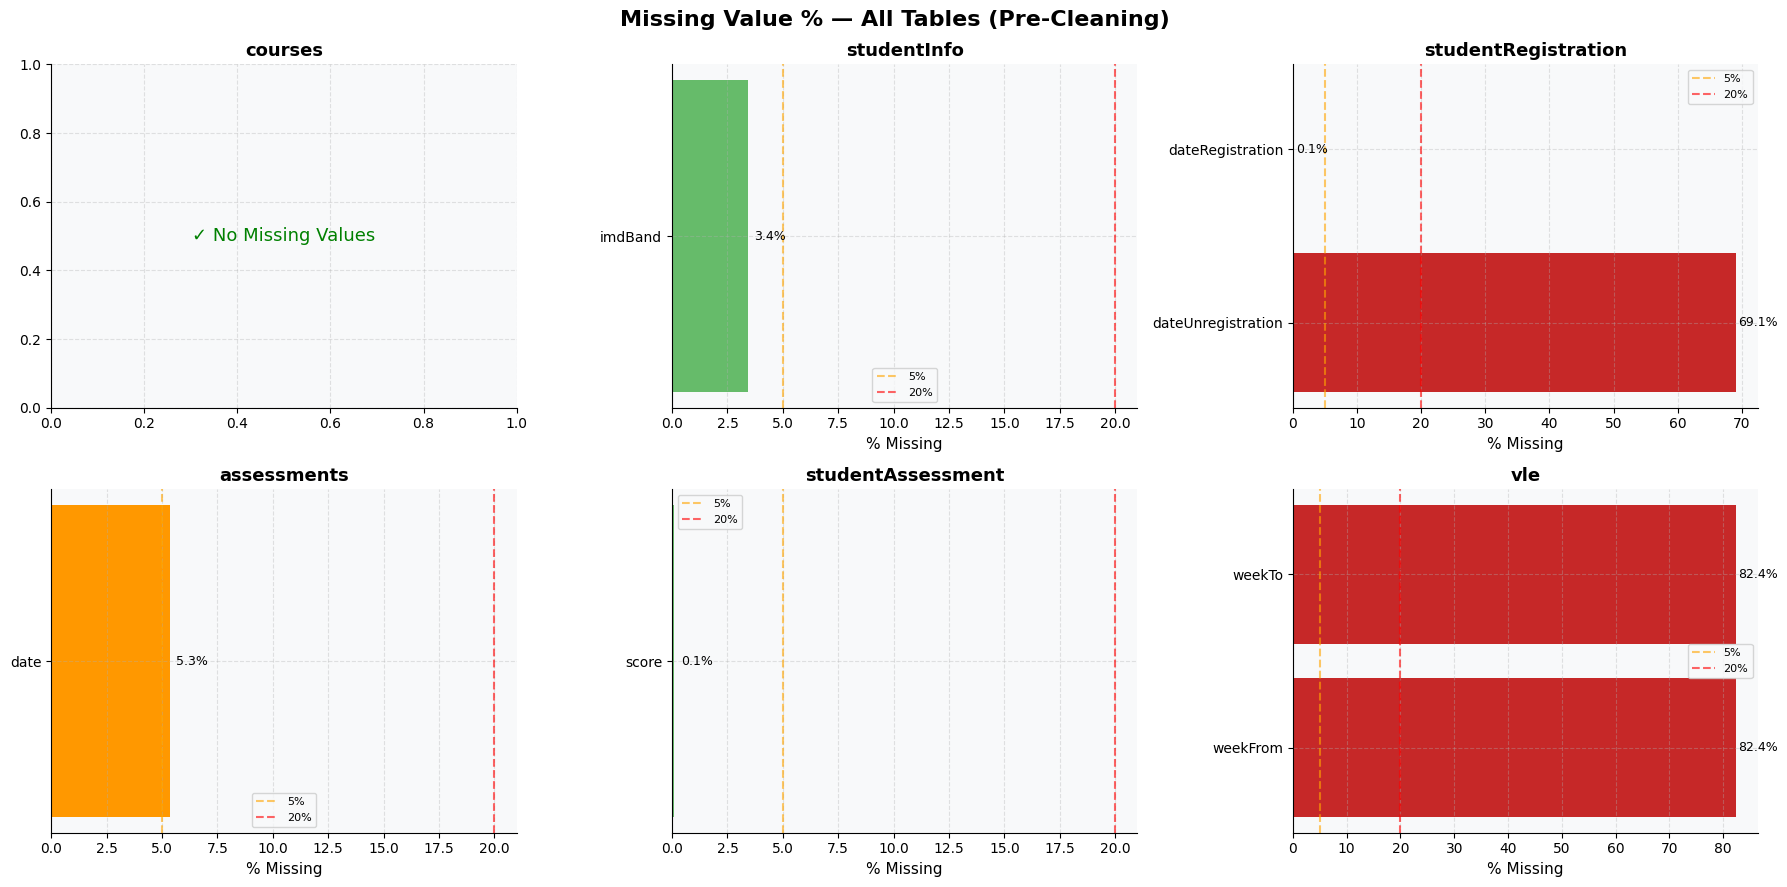

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Missing Value % — All Tables (Pre-Cleaning)')
axes = axes.flatten()
for idx, (name, df) in enumerate(tables.items()):
    miss = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
    miss = miss[miss > 0]
    ax = axes[idx]
    if len(miss) == 0:
        ax.text(0.5,0.5,'✓ No Missing Values',ha='center',va='center',fontsize=13,color='green',transform=ax.transAxes)
    else:
        colors = ['#C62828' if v>20 else '#FF9800' if v>5 else '#66BB6A' for v in miss.values]
        bars = ax.barh(miss.index, miss.values, color=colors)
        for b,v in zip(bars,miss.values):
            ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
        ax.axvline(5,color='orange',ls='--',alpha=0.6,label='5%')
        ax.axvline(20,color='red',ls='--',alpha=0.6,label='20%')
        ax.legend(fontsize=8)
        ax.set_xlabel('% Missing')
    ax.set_title(name)
plt.tight_layout()
plt.savefig(OUT_DIR/'fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


In [55]:
print('── Duplicate Row Check ──')
for name, df in tables.items():
    dups = df.duplicated().sum()
    print(f'  {name:<30} {"✓ CLEAN" if dups==0 else f"⚠ {dups:,} duplicates"}')

print('\n── Key Uniqueness Checks ──')
print(f'  studentInfo  idStudent×module×presentation unique: {not df_info.duplicated(["idStudent","codeModule","codePresentation"]).any()}')
print(f'  assessments  idAssessment unique:                  {not df_assess.duplicated(["idAssessment"]).any()}')
print(f'  studentAssmt idStudent×idAssessment unique:        {not df_sa.duplicated(["idStudent","idAssessment"]).any()}')

print('\n── Outlier Summary (IQR method) ──')
def count_outliers(s):
    Q1,Q3=s.quantile(0.25),s.quantile(0.75); IQR=Q3-Q1
    return ((s<Q1-1.5*IQR)|(s>Q3+1.5*IQR)).sum()

for name, df in tables.items():
    for col in df.select_dtypes(include='number').columns:
        n = count_outliers(df[col].dropna())
        if n>0:
            print(f'  {name}.{col:<35} {n:>6,}  ({n/len(df)*100:.1f}%)')


── Duplicate Row Check ──
  courses                        ✓ CLEAN
  studentInfo                    ✓ CLEAN
  studentRegistration            ✓ CLEAN
  assessments                    ✓ CLEAN
  studentAssessment              ✓ CLEAN
  vle                            ✓ CLEAN

── Key Uniqueness Checks ──
  studentInfo  idStudent×module×presentation unique: True
  assessments  idAssessment unique:                  True
  studentAssmt idStudent×idAssessment unique:        True

── Outlier Summary (IQR method) ──
  studentInfo.idStudent                            6,460  (19.8%)
  studentInfo.numOfPrevAttempts                    4,172  (12.8%)
  studentInfo.studiedCredits                         350  (1.1%)
  studentRegistration.idStudent                            6,460  (19.8%)
  studentRegistration.dateRegistration                       339  (1.0%)
  studentRegistration.dateUnregistration                      41  (0.1%)
  assessments.weight                                  24  (11.7%)
  stud

---
## Section 3 — Strategic Data Cleaning

| Issue | Field | Action | Rationale |
|---|---|---|---|
| 3.4% missing | `imdBand` | Fill `'Unknown'` | Likely admin gap — preserve all rows |
| 0.14% missing | `dateRegistration` | Fill with median | Tiny gap; median robust to outliers |
| 69% null | `dateUnregistration` | Keep as NaN | Null = still enrolled (meaningful) |
| 5.3% missing | `assessments.date` | Module-level median fill | Used only for relative timing |
| 0.1% missing | `studentAssessment.score` | Drop rows | Score is target — imputation invalid |
| 82% missing | `vle.weekFrom/weekTo` | Keep as-is | Not used in primary EDA |


In [56]:
IMD_ORDER = ['0-10%','10-20%','20-30%','30-40%','40-50%',
             '50-60%','60-70%','70-80%','80-90%','90-100%','Unknown']
EDU_ORDER = ['No Formal quals','Lower Than A Level','A Level or Equivalent',
             'HE Qualification','Post Graduate Qualification']
AGE_ORDER = ['0-35','35-55','55<=']

df_info_c = df_info.copy()
df_info_c['imdBand'] = df_info_c['imdBand'].fillna('Unknown')
df_info_c['imd_order'] = pd.Categorical(df_info_c['imdBand'], categories=IMD_ORDER, ordered=True)
df_info_c['edu_order'] = pd.Categorical(df_info_c['highestEducation'], categories=EDU_ORDER, ordered=True)
df_info_c['age_order'] = pd.Categorical(df_info_c['ageBand'], categories=AGE_ORDER, ordered=True)

df_reg_c = df_reg.copy()
df_reg_c['dateRegistration'].fillna(df_reg_c['dateRegistration'].median(), inplace=True)

df_assess_c = df_assess.copy()
df_assess_c['date'] = df_assess_c.groupby(['codeModule','codePresentation'])['date']\
                        .transform(lambda x: x.fillna(x.median()))

df_sa_c = df_sa.copy()
n_dropped = df_sa_c['score'].isna().sum()
df_sa_c.dropna(subset=['score'], inplace=True)

print('Cleaning complete:')
print(f'  studentInfo:   imdBand nulls filled = {df_info["imdBand"].isna().sum()}')
print(f'  registration:  dateRegistration filled = {df_reg["dateRegistration"].isna().sum()}')
print(f'  assessments:   date nulls filled = {df_assess["date"].isna().sum()}')
print(f'  studentAssmt:  score rows dropped = {n_dropped}')
print(f'  Remaining nulls in cleaned info: {df_info_c.isnull().sum().sum()}')


Cleaning complete:
  studentInfo:   imdBand nulls filled = 1111
  registration:  dateRegistration filled = 45
  assessments:   date nulls filled = 11
  studentAssmt:  score rows dropped = 173
  Remaining nulls in cleaned info: 3516


In [57]:
df_master = df_info_c.merge(
    df_reg_c[['idStudent','codeModule','codePresentation',
              'dateRegistration','dateUnregistration']],
    on=['idStudent','codeModule','codePresentation'], how='left'
).merge(
    df_courses[['codeModule','codePresentation','modulePresentationLength']],
    on=['codeModule','codePresentation'], how='left'
)
df_master['outcome_binary'] = df_master['finalResult'].map(
    {'Distinction':'Success','Pass':'Success','Fail':'Failure','Withdrawn':'Failure'})
df_master['is_dropout']  = (df_master['finalResult']=='Withdrawn').astype(int)
df_master['is_success']  = df_master['finalResult'].isin(['Pass','Distinction']).astype(int)
df_master['reg_timing']  = pd.cut(df_master['dateRegistration'],
    bins=[-400,-100,-30,0,200], labels=['Very Early','>30d Before','0-30d Before','After Start'])

n = len(df_master)
print(f'Master dataset: {df_master.shape}')
print(f'\nOutcome distribution:')
for r in OUTCOME_ORDER:
    print(f'  {r:<15} {pct((df_master["finalResult"]==r).sum(), n)}')
print(f'\nOverall Success Rate: {df_master["is_success"].mean()*100:.1f}%')
print(f'Overall Dropout Rate: {df_master["is_dropout"].mean()*100:.1f}%')


Master dataset: (32593, 22)

Outcome distribution:
  Distinction     3,024  (9.3%)
  Pass            12,361  (37.9%)
  Fail            7,052  (21.6%)
  Withdrawn       10,156  (31.2%)

Overall Success Rate: 47.2%
Overall Dropout Rate: 31.2%


---
## Section 4 — EDA: Student Demographics


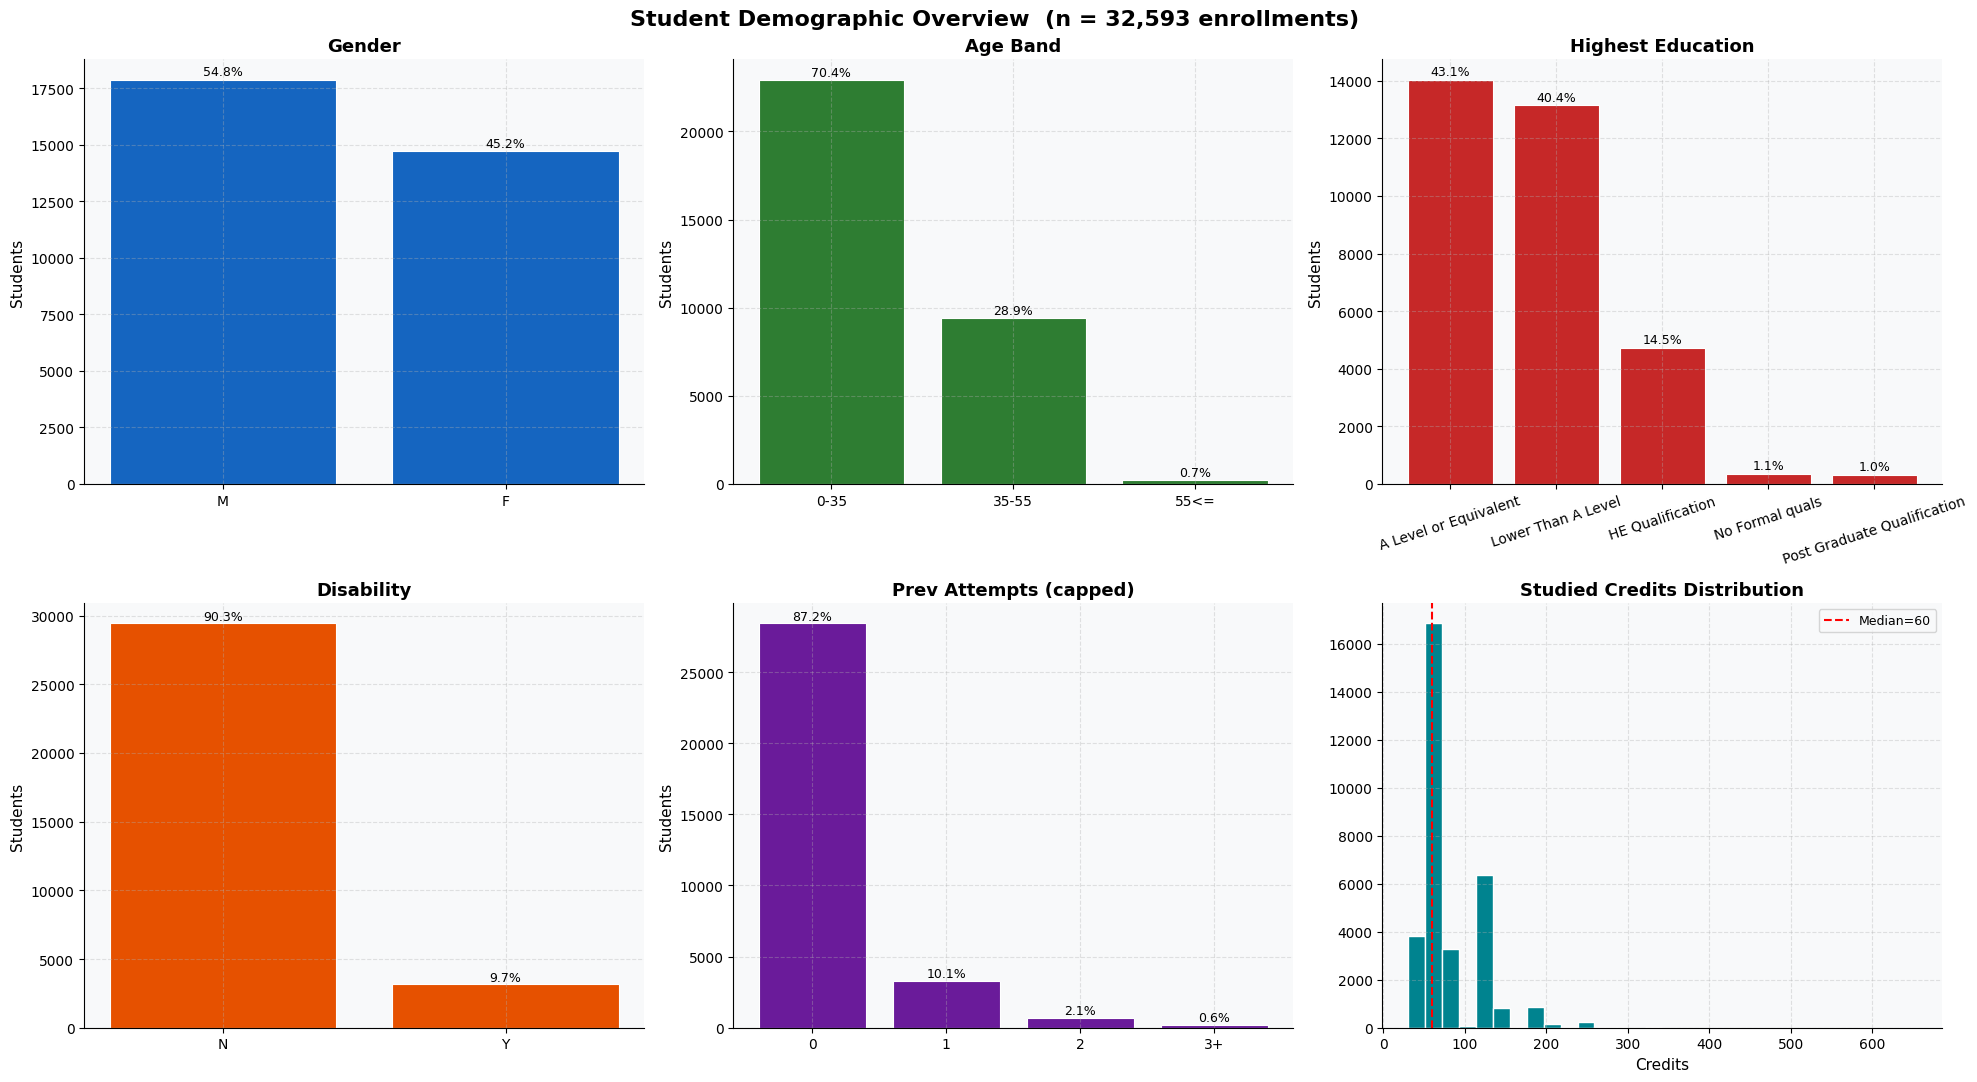

In [58]:
# 4A — Demographic distribution overview
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Student Demographic Overview  (n = 32,593 enrollments)')
axes = axes.flatten()

def annotated_bar(ax, series, title, color, rot=0):
    vc = series.value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values, color=color, edgecolor='white', linewidth=0.8)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+50,
                f'{b.get_height()/len(series)*100:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(title); ax.set_ylabel('Students'); ax.tick_params(axis='x', rotation=rot)

annotated_bar(axes[0], df_master['gender'],           'Gender',              CAT_COLORS[0])
annotated_bar(axes[1], df_master['ageBand'],           'Age Band',            CAT_COLORS[1])
annotated_bar(axes[2], df_master['highestEducation'],  'Highest Education',   CAT_COLORS[2], rot=18)
annotated_bar(axes[3], df_master['disability'],        'Disability',          CAT_COLORS[3])
annotated_bar(axes[4], df_master['numOfPrevAttempts'].clip(upper=3).replace(3,'3+'),
              'Prev Attempts (capped)', CAT_COLORS[4])
# Credits distribution
axes[5].hist(df_master['studiedCredits'], bins=30, color=CAT_COLORS[5], edgecolor='white')
axes[5].set_title('Studied Credits Distribution')
axes[5].axvline(df_master['studiedCredits'].median(), color='red', ls='--',
                label=f'Median={df_master["studiedCredits"].median():.0f}')
axes[5].legend(); axes[5].set_xlabel('Credits')

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_demographics_overview.png', dpi=150, bbox_inches='tight')
plt.show()


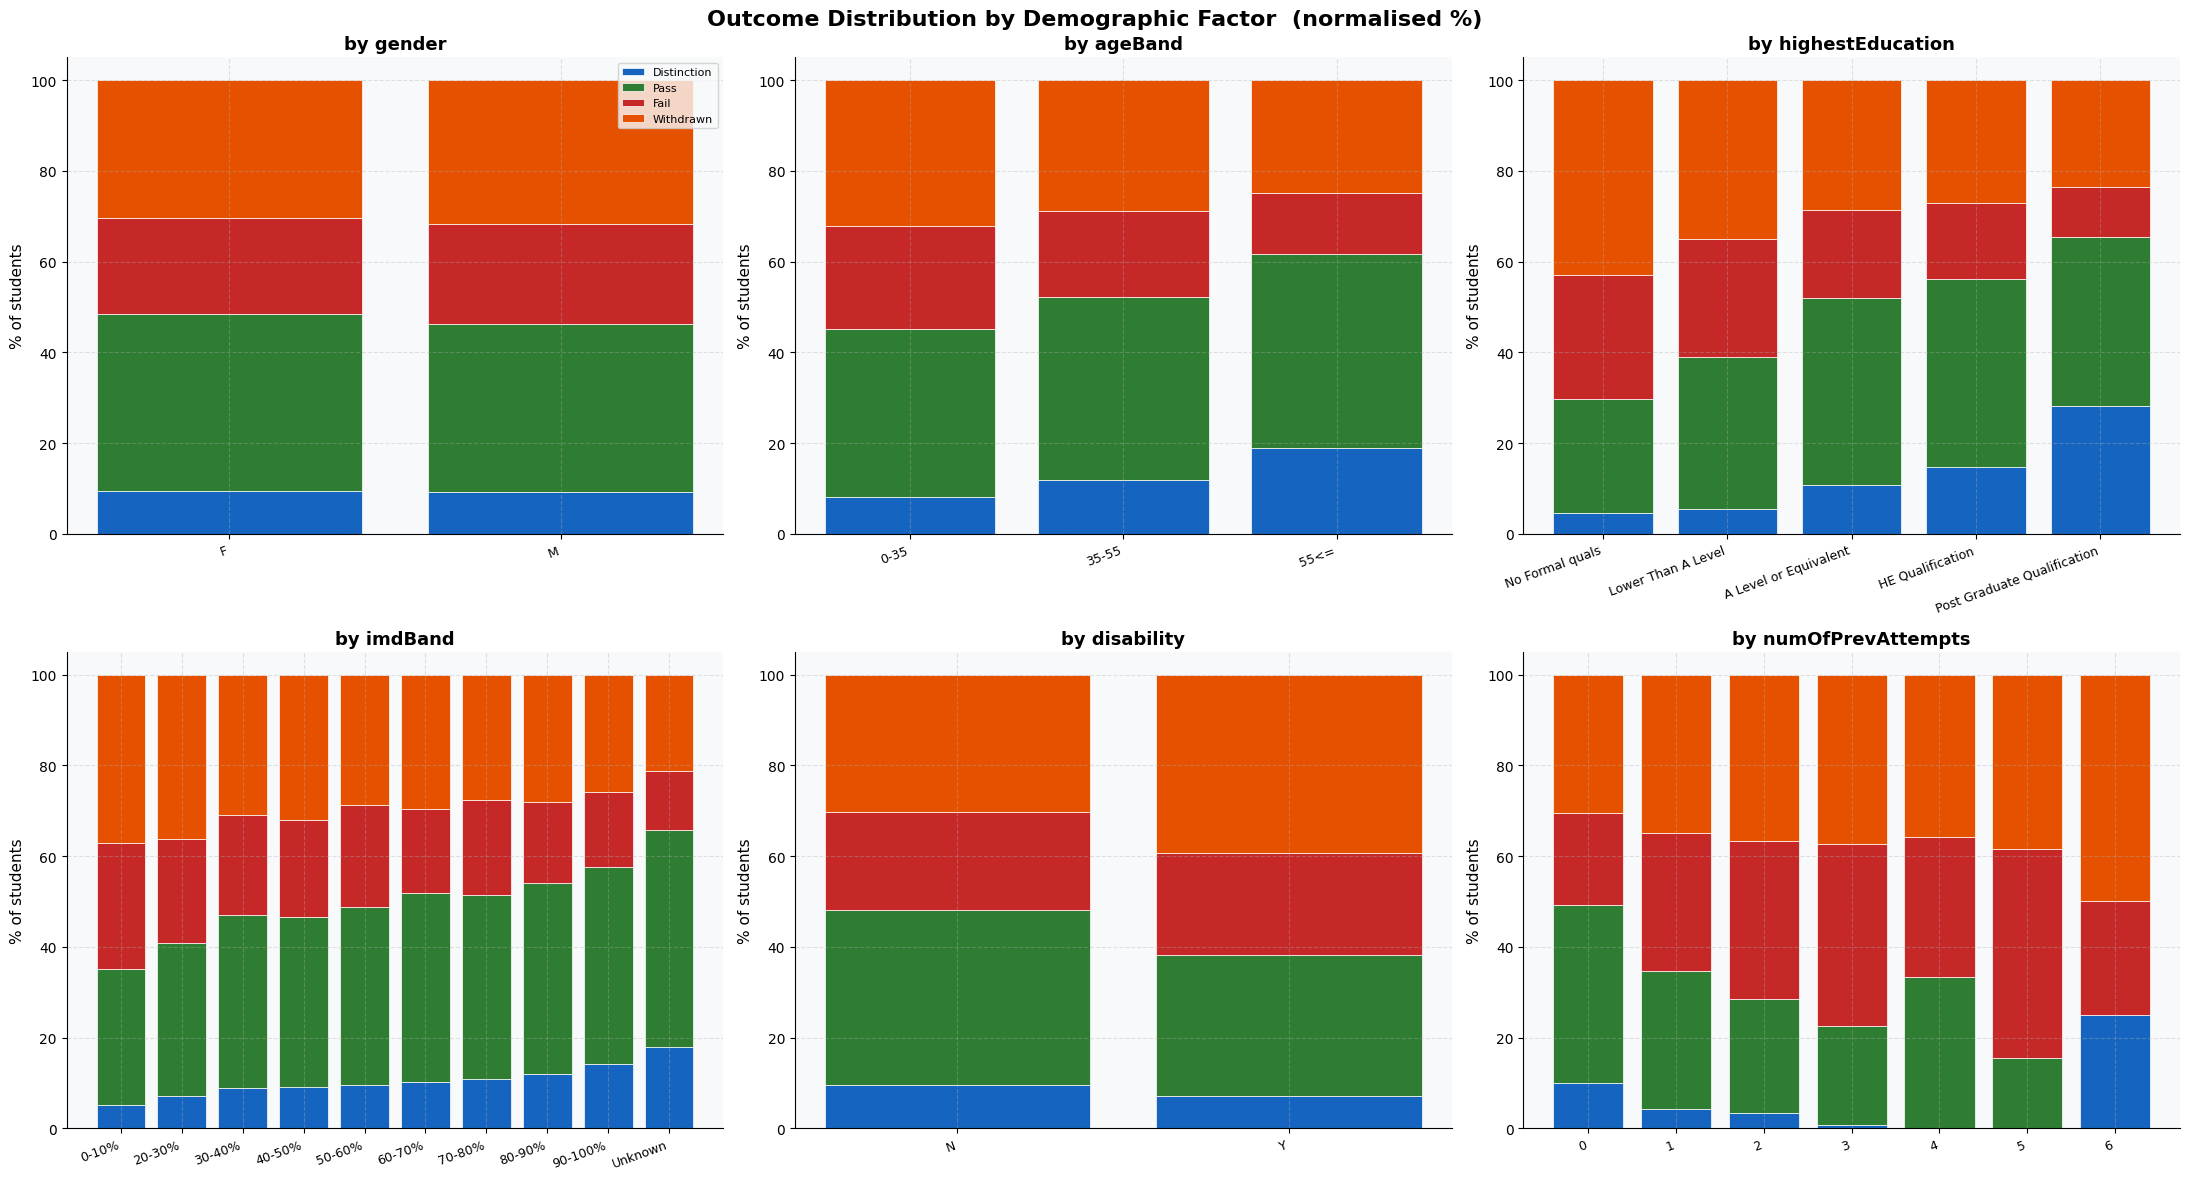

In [59]:
# 4B — Final outcome proportions by every demographic (normalised stacked bars)
demo_cols = ['gender','ageBand','highestEducation','imdBand','disability','numOfPrevAttempts']
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Outcome Distribution by Demographic Factor  (normalised %)')
axes = axes.flatten()

for idx, col in enumerate(demo_cols):
    ct = pd.crosstab(df_master[col], df_master['finalResult'], normalize='index')[OUTCOME_ORDER]*100
    if col == 'imdBand':
        ct = ct.reindex([c for c in IMD_ORDER if c in ct.index])
    elif col == 'highestEducation':
        ct = ct.reindex([c for c in EDU_ORDER if c in ct.index])
    bottom = np.zeros(len(ct))
    for outcome, color in zip(OUTCOME_ORDER, OUTCOME_COLORS):
        if outcome in ct.columns:
            axes[idx].bar(range(len(ct)), ct[outcome].values, bottom=bottom,
                          color=color, label=outcome, edgecolor='white', linewidth=0.5)
            bottom += ct[outcome].values
    axes[idx].set_xticks(range(len(ct)))
    axes[idx].set_xticklabels(ct.index.astype(str), rotation=20, ha='right', fontsize=9)
    axes[idx].set_ylabel('% of students'); axes[idx].set_title(f'by {col}')
    axes[idx].set_ylim(0,105)
    if idx == 0:
        axes[idx].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_outcome_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


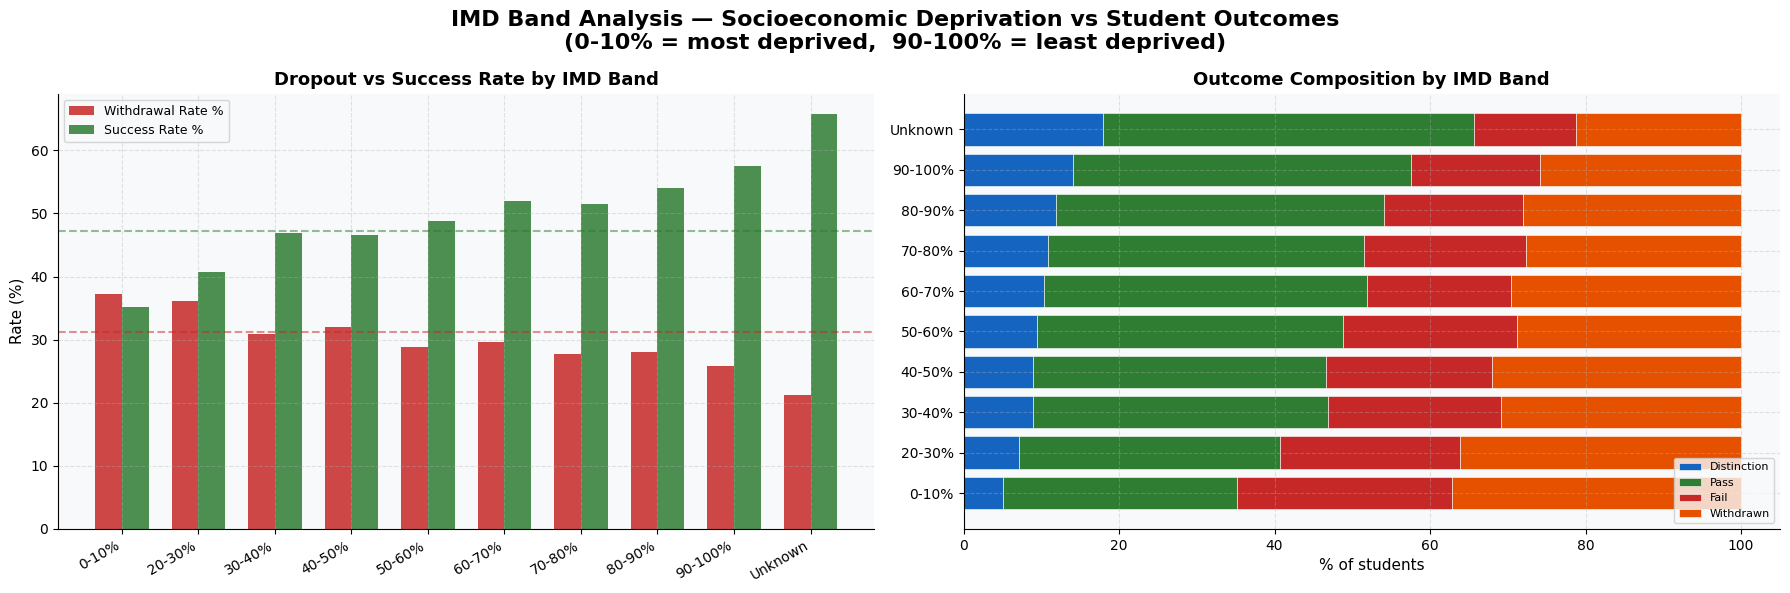


Key finding: Lower IMD bands (more deprived) show higher withdrawal and lower success rates.


In [60]:
# 4C — IMD Band (Socioeconomic Deprivation) deep-dive
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('IMD Band Analysis — Socioeconomic Deprivation vs Student Outcomes\n'
             '(0-10% = most deprived,  90-100% = least deprived)')

imd_order_present = [b for b in IMD_ORDER if b in df_master['imdBand'].values]
dropout_by_imd = df_master.groupby('imdBand')['is_dropout'].mean()*100
success_by_imd = df_master.groupby('imdBand')['is_success'].mean()*100
count_by_imd   = df_master.groupby('imdBand').size()

x = range(len(imd_order_present))
width = 0.35
axes[0].bar([i-width/2 for i in x],
            [dropout_by_imd.get(b,0) for b in imd_order_present],
            width, color='#C62828', alpha=0.85, label='Withdrawal Rate %')
axes[0].bar([i+width/2 for i in x],
            [success_by_imd.get(b,0) for b in imd_order_present],
            width, color='#2E7D32', alpha=0.85, label='Success Rate %')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(imd_order_present, rotation=30, ha='right')
axes[0].set_ylabel('Rate (%)'); axes[0].set_title('Dropout vs Success Rate by IMD Band')
axes[0].legend(); axes[0].axhline(df_master['is_dropout'].mean()*100, color='#C62828', ls='--', alpha=0.5)
axes[0].axhline(df_master['is_success'].mean()*100, color='#2E7D32', ls='--', alpha=0.5)

ct_imd = pd.crosstab(df_master['imdBand'], df_master['finalResult'], normalize='index')[OUTCOME_ORDER]*100
ct_imd = ct_imd.reindex([b for b in IMD_ORDER if b in ct_imd.index])
bottom = np.zeros(len(ct_imd))
for outcome, color in zip(OUTCOME_ORDER, OUTCOME_COLORS):
    if outcome in ct_imd.columns:
        axes[1].barh(range(len(ct_imd)), ct_imd[outcome].values, left=bottom,
                     color=color, label=outcome, edgecolor='white', linewidth=0.4)
        bottom += ct_imd[outcome].values
axes[1].set_yticks(range(len(ct_imd))); axes[1].set_yticklabels(ct_imd.index)
axes[1].set_xlabel('% of students'); axes[1].set_title('Outcome Composition by IMD Band')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_imd_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey finding: Lower IMD bands (more deprived) show higher withdrawal and lower success rates.')


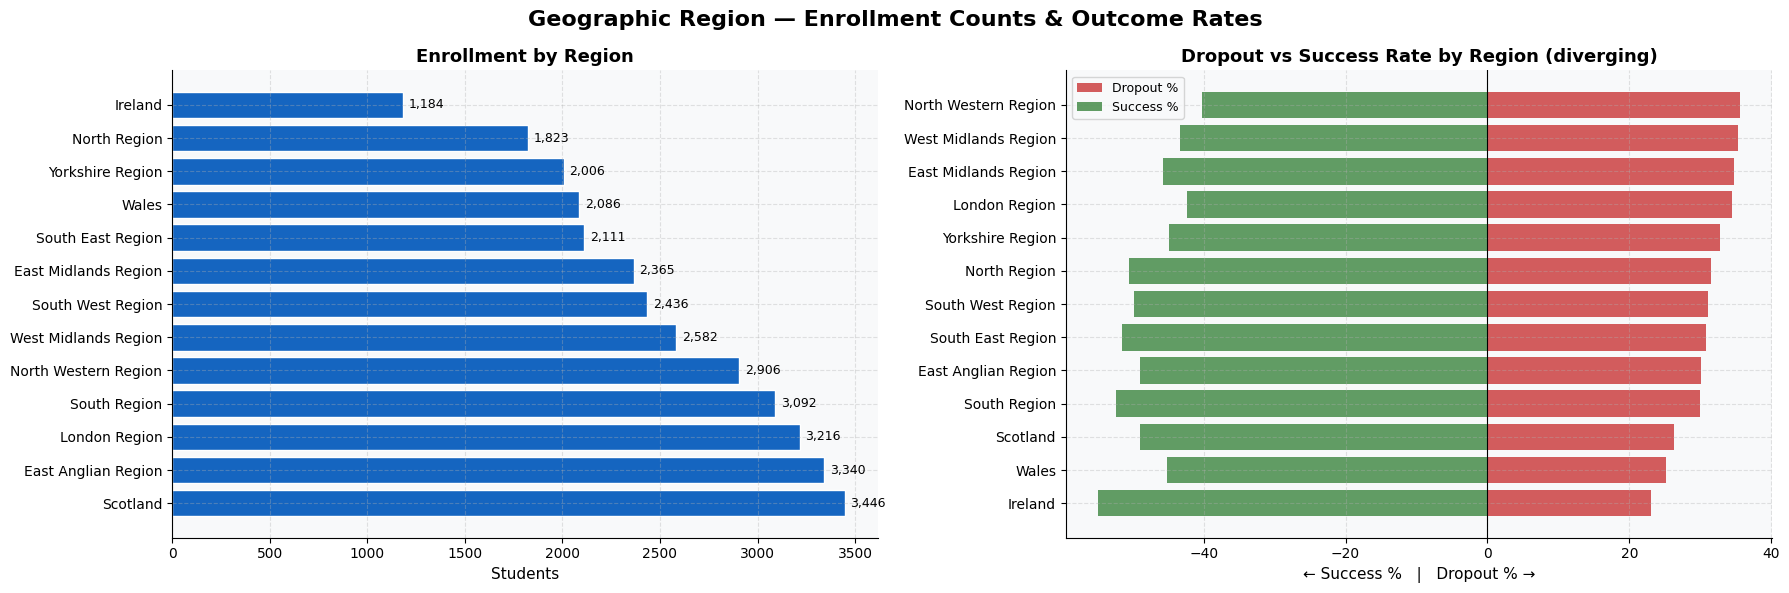

In [61]:
# 4D — Region analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Geographic Region — Enrollment Counts & Outcome Rates')

region_counts = df_master['region'].value_counts()
axes[0].barh(region_counts.index, region_counts.values, color=CAT_COLORS[0], edgecolor='white')
for i, v in enumerate(region_counts.values):
    axes[0].text(v+30, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_title('Enrollment by Region'); axes[0].set_xlabel('Students')

region_out = df_master.groupby('region')[['is_dropout','is_success']].mean()*100
region_out = region_out.sort_values('is_dropout', ascending=True)
axes[1].barh(region_out.index, region_out['is_dropout'], color='#C62828', alpha=0.75, label='Dropout %')
axes[1].barh(region_out.index, -region_out['is_success'], color='#2E7D32', alpha=0.75, label='Success %')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('← Success %   |   Dropout % →')
axes[1].set_title('Dropout vs Success Rate by Region (diverging)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_region_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


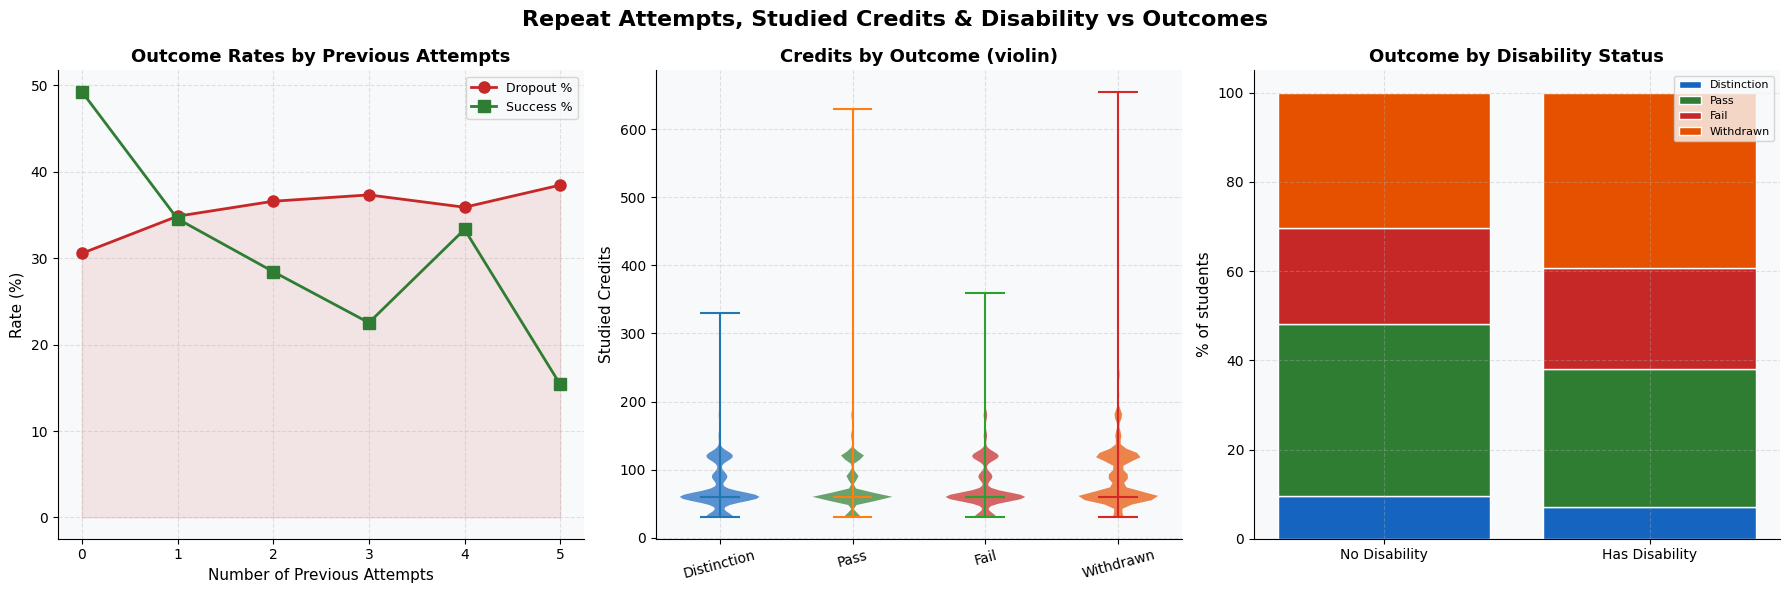

In [62]:
# 4E — Previous attempts, studied credits & disability
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Repeat Attempts, Studied Credits & Disability vs Outcomes')

# Previous attempts vs dropout rate
prev_stats = df_master.groupby('numOfPrevAttempts')[['is_dropout','is_success']].mean()*100
prev_stats = prev_stats[prev_stats.index <= 5]
axes[0].plot(prev_stats.index, prev_stats['is_dropout'], 'o-', color='#C62828', lw=2, ms=8, label='Dropout %')
axes[0].plot(prev_stats.index, prev_stats['is_success'], 's-', color='#2E7D32', lw=2, ms=8, label='Success %')
axes[0].set_xlabel('Number of Previous Attempts'); axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Outcome Rates by Previous Attempts'); axes[0].legend()
axes[0].fill_between(prev_stats.index, prev_stats['is_dropout'], alpha=0.1, color='#C62828')

# Credits distribution by outcome (violin)
for i, outcome in enumerate(OUTCOME_ORDER):
    data = df_master[df_master['finalResult']==outcome]['studiedCredits']
    parts = axes[1].violinplot(data, positions=[i], widths=0.6, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(OUTCOME_COLORS[i]); pc.set_alpha(0.7)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(OUTCOME_ORDER, rotation=15)
axes[1].set_ylabel('Studied Credits'); axes[1].set_title('Credits by Outcome (violin)')

# Disability vs outcome
dis_ct = pd.crosstab(df_master['disability'], df_master['finalResult'], normalize='index')[OUTCOME_ORDER]*100
bottom = np.zeros(2)
for outcome, color in zip(OUTCOME_ORDER, OUTCOME_COLORS):
    axes[2].bar(['No Disability','Has Disability'], dis_ct[outcome].values,
                bottom=bottom, color=color, label=outcome, edgecolor='white')
    bottom += dis_ct[outcome].values
axes[2].set_ylabel('% of students'); axes[2].set_title('Outcome by Disability Status'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_attempts_credits_disability.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 5 — Course & Module Analysis


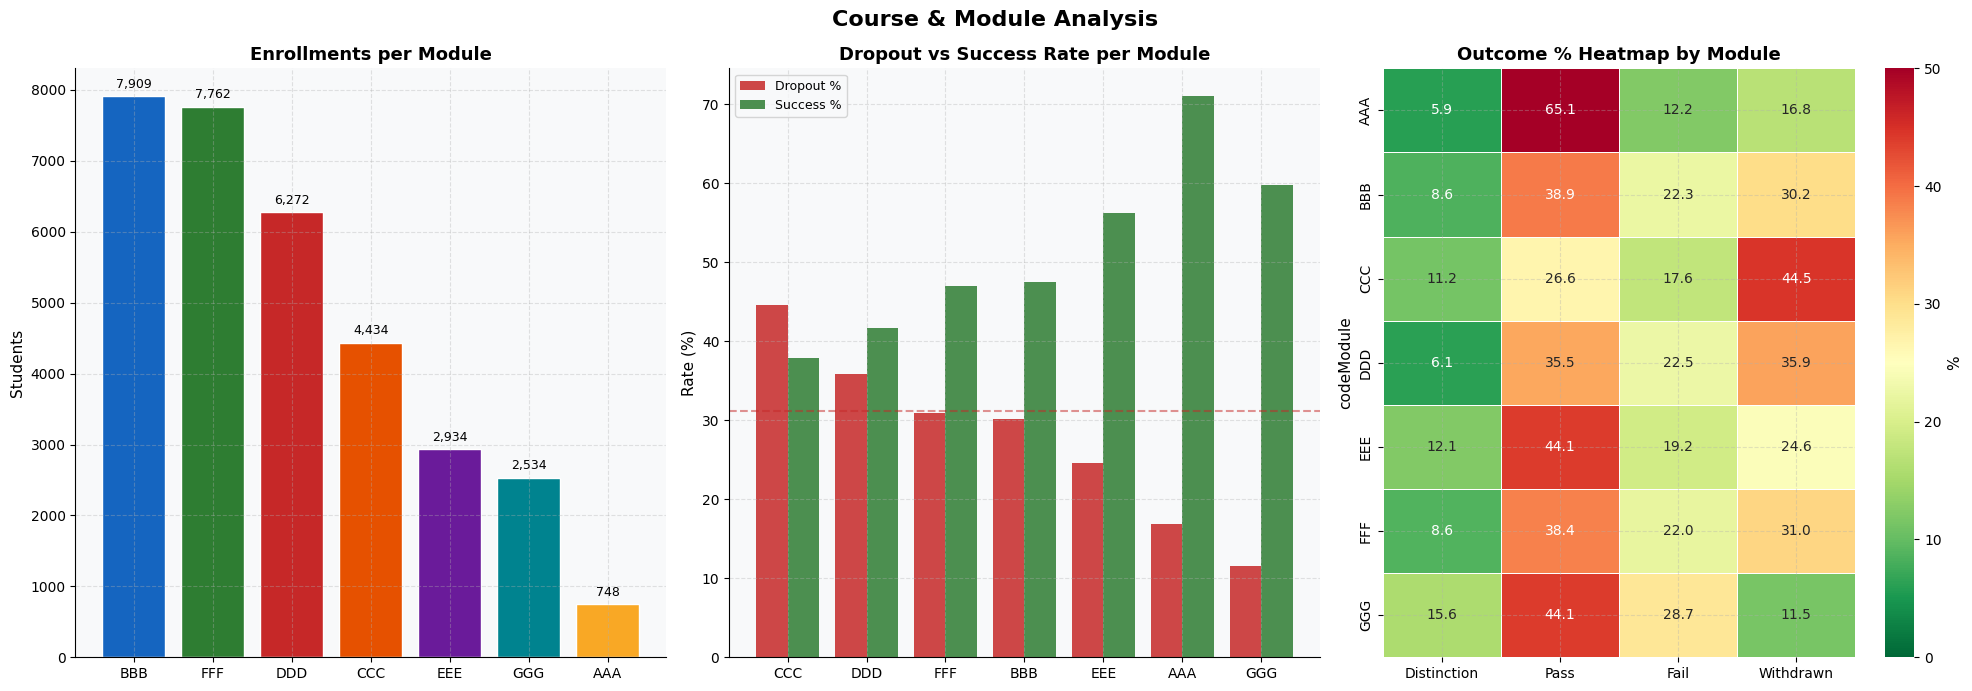

In [63]:
# 5A — Module enrollment, presentation periods & difficulty
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Course & Module Analysis')

# Enrollment per module
mod_enroll = df_master['codeModule'].value_counts()
bars = axes[0].bar(mod_enroll.index, mod_enroll.values, color=CAT_COLORS, edgecolor='white')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+80,
                 f'{b.get_height():,}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Enrollments per Module'); axes[0].set_ylabel('Students')

# Module-level dropout rate (sorted)
mod_dropout = df_master.groupby('codeModule')['is_dropout'].mean()*100
mod_success = df_master.groupby('codeModule')['is_success'].mean()*100
mod_dropout = mod_dropout.sort_values(ascending=False)
x = range(len(mod_dropout))
axes[1].bar([i-0.2 for i in x], mod_dropout.values, 0.4, color='#C62828', alpha=0.85, label='Dropout %')
axes[1].bar([i+0.2 for i in x], mod_success.reindex(mod_dropout.index).values, 0.4,
            color='#2E7D32', alpha=0.85, label='Success %')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(mod_dropout.index)
axes[1].set_title('Dropout vs Success Rate per Module')
axes[1].legend(); axes[1].set_ylabel('Rate (%)')
axes[1].axhline(df_master['is_dropout'].mean()*100, color='#C62828', ls='--', alpha=0.5)

# Outcome heatmap: module × finalResult (%)
mod_ct = pd.crosstab(df_master['codeModule'], df_master['finalResult'], normalize='index')[OUTCOME_ORDER]*100
sns.heatmap(mod_ct, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[2],
            linewidths=0.5, cbar_kws={'label':'%'}, vmin=0, vmax=50)
axes[2].set_title('Outcome % Heatmap by Module'); axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_module_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 6 — Outcome Deep Dive


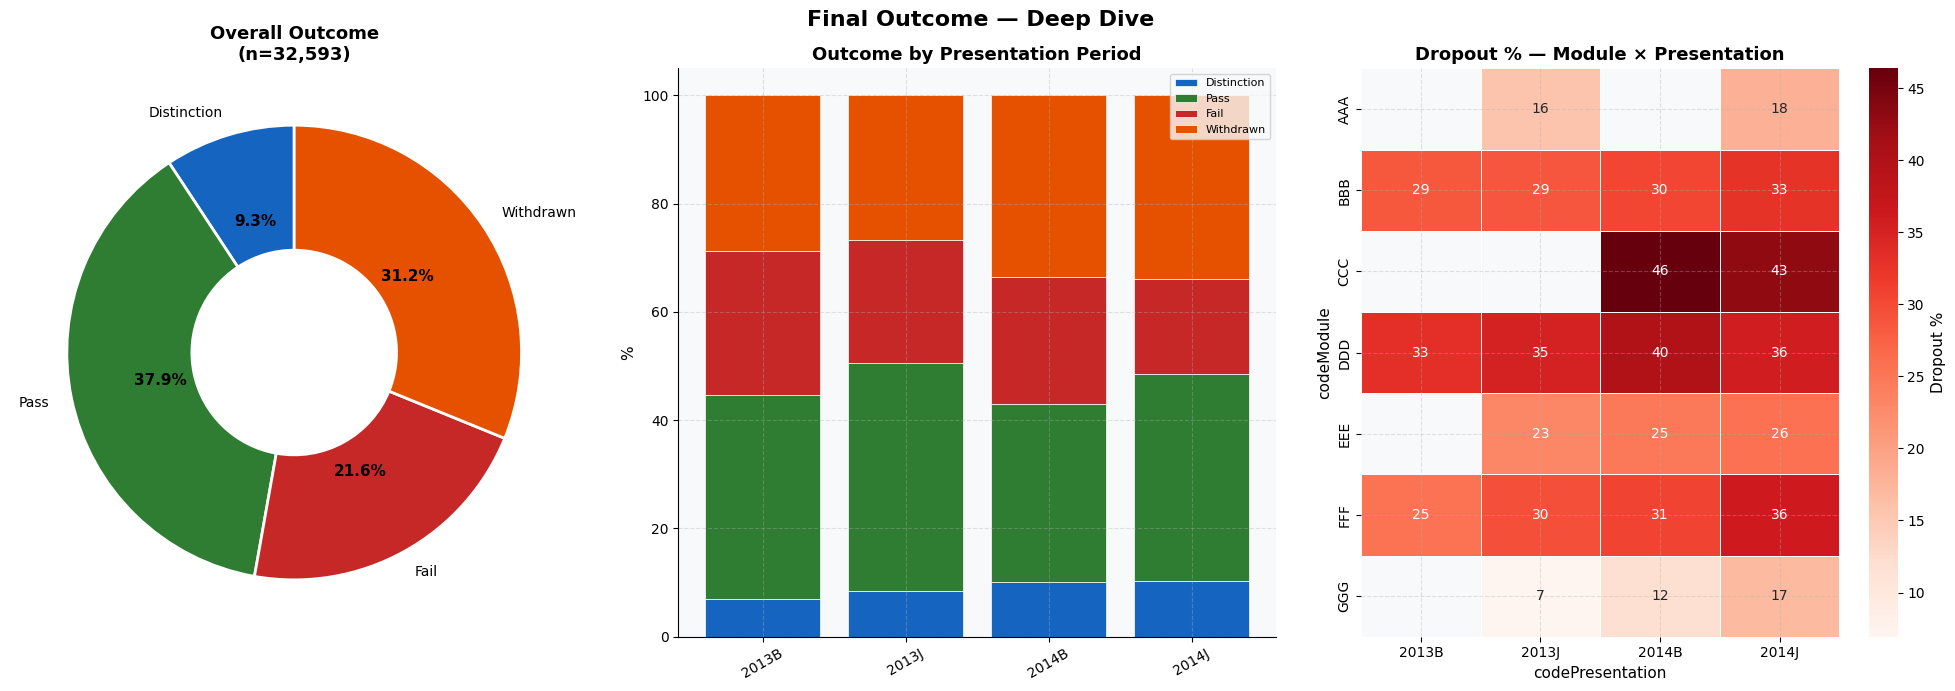

In [64]:
# 6A — Outcome distribution + presentation-level breakdown
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Final Outcome — Deep Dive')

# Donut chart
counts = df_master['finalResult'].value_counts().reindex(OUTCOME_ORDER)
wedges, texts, autotexts = axes[0].pie(
    counts.values, labels=OUTCOME_ORDER, colors=OUTCOME_COLORS,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold')
axes[0].set_title(f'Overall Outcome\n(n={len(df_master):,})')

# Outcome by codePresentation (semester/year)
pres_ct = pd.crosstab(df_master['codePresentation'], df_master['finalResult'],
                      normalize='index')[OUTCOME_ORDER]*100
bottom = np.zeros(len(pres_ct))
for outcome, color in zip(OUTCOME_ORDER, OUTCOME_COLORS):
    axes[1].bar(pres_ct.index, pres_ct[outcome].values, bottom=bottom,
                color=color, label=outcome, edgecolor='white', linewidth=0.5)
    bottom += pres_ct[outcome].values
axes[1].set_title('Outcome by Presentation Period'); axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30); axes[1].legend(fontsize=8)

# Success & dropout rates by module × presentation heatmap
mp_dropout = df_master.groupby(['codeModule','codePresentation'])['is_dropout'].mean()*100
mp_pivot = mp_dropout.unstack()
sns.heatmap(mp_pivot, annot=True, fmt='.0f', cmap='Reds', ax=axes[2],
            linewidths=0.5, cbar_kws={'label':'Dropout %'})
axes[2].set_title('Dropout % — Module × Presentation')

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_outcome_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 7 — Registration & Withdrawal Patterns


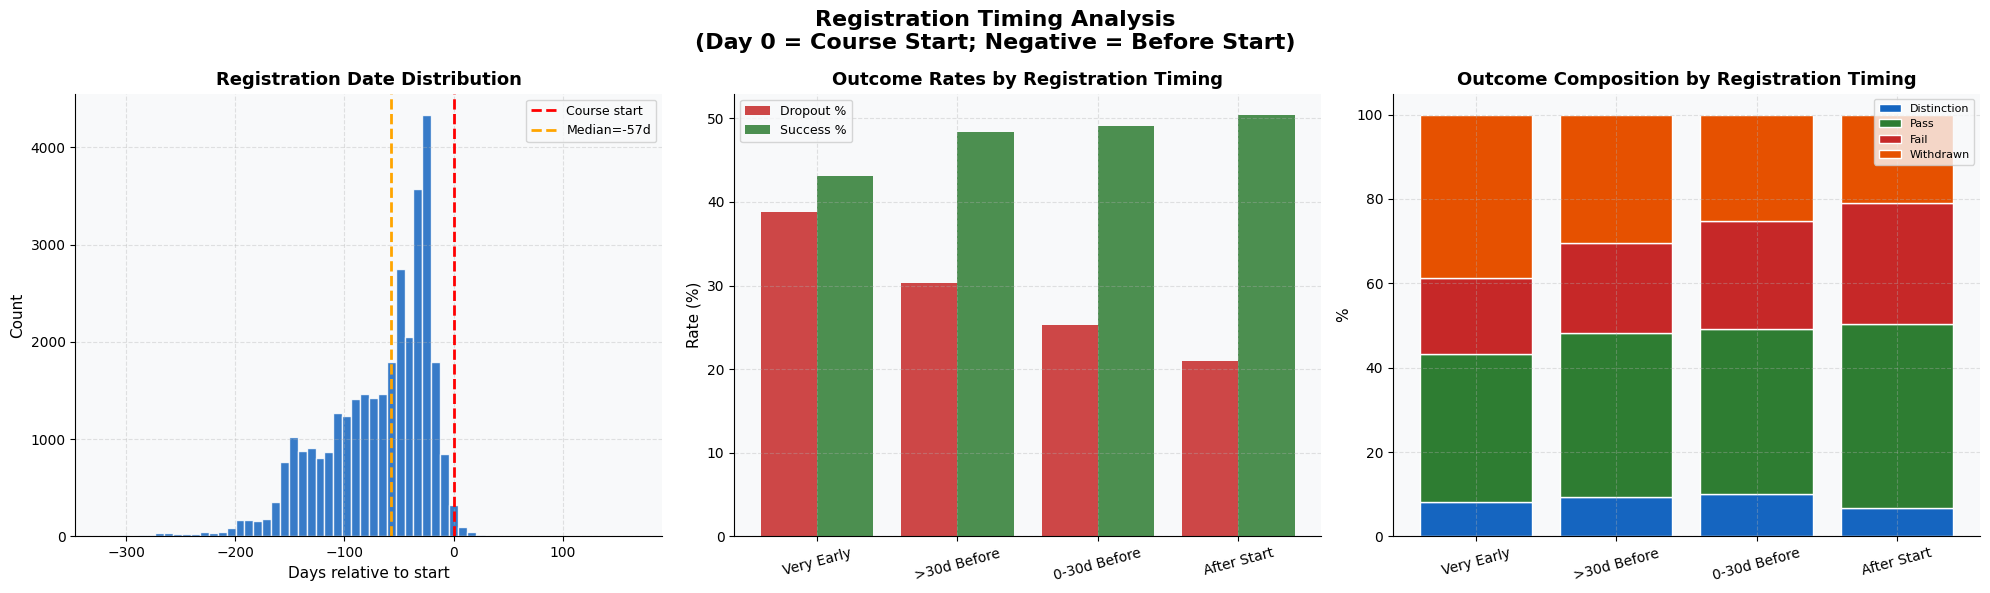

In [65]:
# 7A — Registration timing patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Registration Timing Analysis\n(Day 0 = Course Start; Negative = Before Start)')

axes[0].hist(df_master['dateRegistration'].dropna(), bins=60, color='#1565C0', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', ls='--', lw=2, label='Course start')
axes[0].axvline(df_master['dateRegistration'].median(), color='orange', ls='--', lw=2,
                label=f'Median={df_master["dateRegistration"].median():.0f}d')
axes[0].set_title('Registration Date Distribution'); axes[0].set_xlabel('Days relative to start')
axes[0].legend(); axes[0].set_ylabel('Count')

reg_out = df_master.groupby('reg_timing')[['is_dropout','is_success']].mean()*100
reg_out = reg_out.reindex(['Very Early','>30d Before','0-30d Before','After Start'])
x = range(len(reg_out))
axes[1].bar([i-0.2 for i in x], reg_out['is_dropout'].values, 0.4,
            color='#C62828', alpha=0.85, label='Dropout %')
axes[1].bar([i+0.2 for i in x], reg_out['is_success'].values, 0.4,
            color='#2E7D32', alpha=0.85, label='Success %')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(reg_out.index, rotation=15)
axes[1].set_title('Outcome Rates by Registration Timing')
axes[1].legend(); axes[1].set_ylabel('Rate (%)')

reg_ct = pd.crosstab(df_master['reg_timing'], df_master['finalResult'], normalize='index')[OUTCOME_ORDER]*100
reg_ct = reg_ct.reindex([r for r in ['Very Early','>30d Before','0-30d Before','After Start'] if r in reg_ct.index])
bottom = np.zeros(len(reg_ct))
for outcome, color in zip(OUTCOME_ORDER, OUTCOME_COLORS):
    axes[2].bar(reg_ct.index, reg_ct[outcome].values, bottom=bottom,
                color=color, label=outcome, edgecolor='white')
    bottom += reg_ct[outcome].values
axes[2].set_title('Outcome Composition by Registration Timing')
axes[2].tick_params(axis='x', rotation=15); axes[2].set_ylabel('%'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_registration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


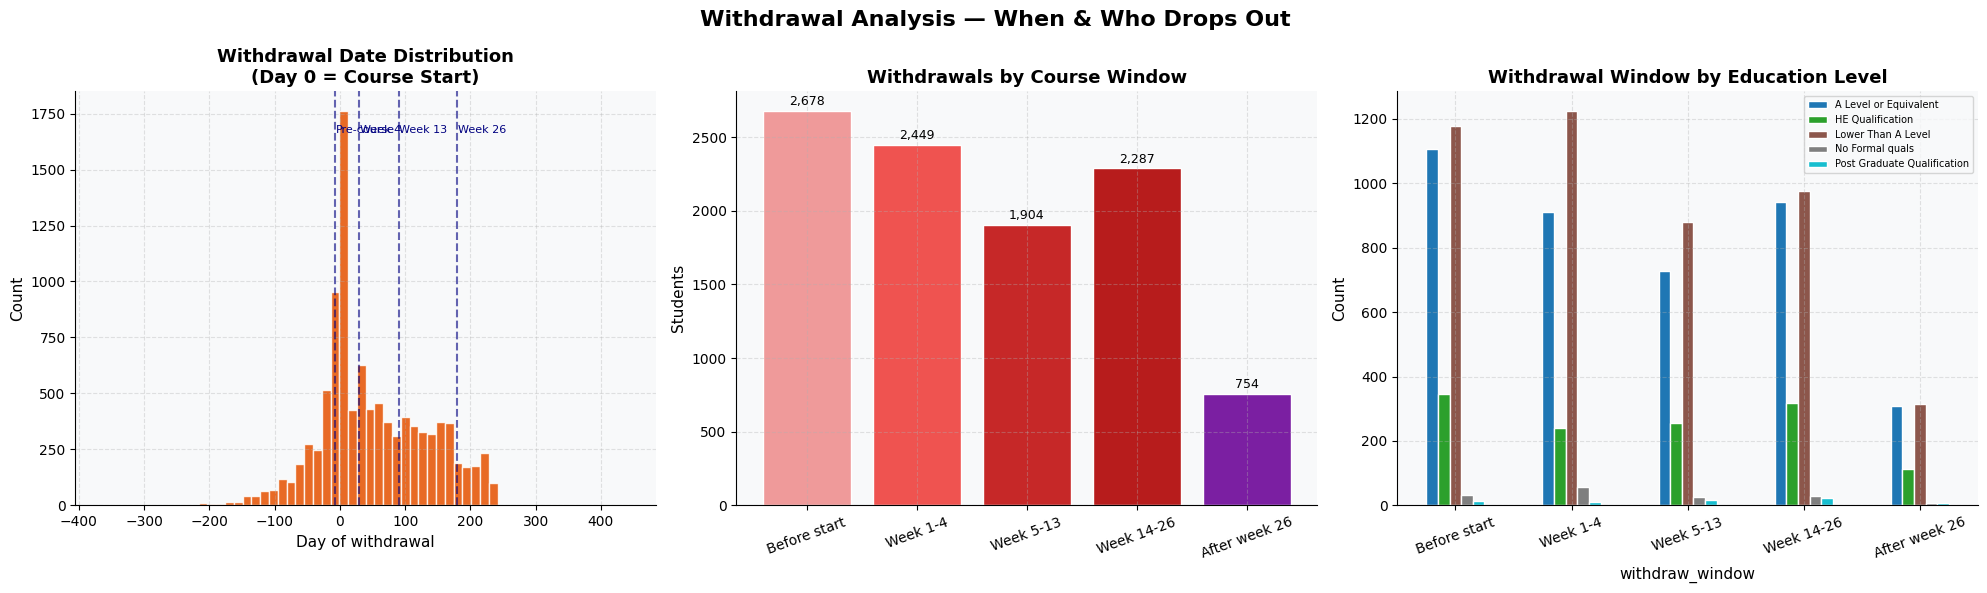


Median withdrawal day: 27
50% of withdrawals happen before day 27
25% of withdrawals happen before day -2  (early dropout risk window)


In [66]:
# 7B — Withdrawal timing & risk windows
withdrawn_dates = df_master[
    (df_master['finalResult']=='Withdrawn') & df_master['dateUnregistration'].notna()
]['dateUnregistration']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Withdrawal Analysis — When & Who Drops Out')

axes[0].hist(withdrawn_dates, bins=60, color='#E65100', edgecolor='white', alpha=0.85)
for v, lbl in [(-7,'Pre-course'), (30,'Week 4'), (90,'Week 13'), (180,'Week 26')]:
    axes[0].axvline(v, color='navy', ls='--', alpha=0.6)
    axes[0].text(v+1, axes[0].get_ylim()[1]*0.9, lbl, fontsize=8, color='navy')
axes[0].set_title('Withdrawal Date Distribution\n(Day 0 = Course Start)')
axes[0].set_xlabel('Day of withdrawal'); axes[0].set_ylabel('Count')

bins = [-400,-1,30,90,180,500]
labels = ['Before start','Week 1-4','Week 5-13','Week 14-26','After week 26']
df_master['withdraw_window'] = pd.cut(df_master['dateUnregistration'], bins=bins, labels=labels)
ww_counts = df_master['withdraw_window'].value_counts().reindex(labels)
axes[1].bar(labels, ww_counts.values, color=['#EF9A9A','#EF5350','#C62828','#B71C1C','#7B1FA2'],
            edgecolor='white')
for i, v in enumerate(ww_counts.values):
    if not pd.isna(v):
        axes[1].text(i, v+20, f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Withdrawals by Course Window'); axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Students')

ww_by_edu = df_master[df_master['finalResult']=='Withdrawn'].groupby(
    ['withdraw_window','highestEducation']).size().unstack(fill_value=0)
ww_by_edu = ww_by_edu.reindex([l for l in labels if l in ww_by_edu.index])
ww_by_edu.plot(kind='bar', ax=axes[2], colormap='tab10', edgecolor='white')
axes[2].set_title('Withdrawal Window by Education Level')
axes[2].tick_params(axis='x', rotation=20); axes[2].legend(fontsize=7, loc='upper right')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_withdrawal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nMedian withdrawal day: {withdrawn_dates.median():.0f}')
print(f'50% of withdrawals happen before day {withdrawn_dates.quantile(0.5):.0f}')
print(f'25% of withdrawals happen before day {withdrawn_dates.quantile(0.25):.0f}  (early dropout risk window)')


---
## Section 8 — Assessment Performance Analysis


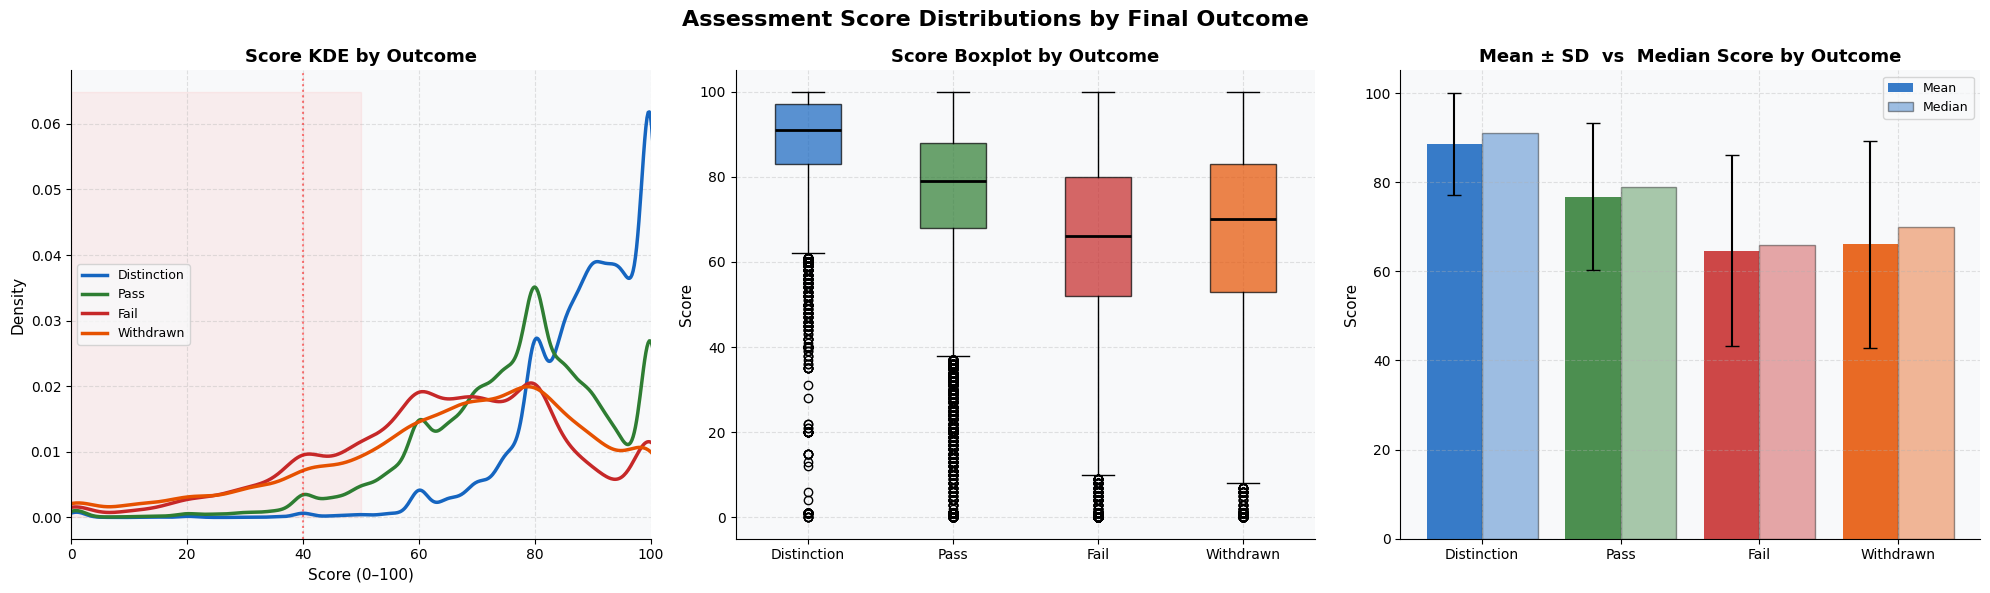


Score statistics by outcome:
                 count   mean    std   min    25%    50%    75%     max
finalResult                                                            
Distinction  26330.000 88.680 11.440 0.000 83.000 91.000 97.000 100.000
Pass        105987.000 76.770 16.460 0.000 68.000 79.000 88.000 100.000
Fail         28399.000 64.690 21.430 0.000 52.000 66.000 80.000 100.000
Withdrawn    13023.000 66.080 23.180 0.000 53.000 70.000 83.000 100.000


In [67]:
# 8A — Assessment score distributions by outcome (KDE + box)
df_sa_merged = df_sa_c.merge(
    df_assess_c[['idAssessment','assessmentType','weight','date','codeModule','codePresentation']],
    on='idAssessment', how='left'
).merge(
    df_info_c[['idStudent','codeModule','codePresentation','finalResult']],
    on=['idStudent','codeModule','codePresentation'], how='left'
)
df_sa_merged['submission_delay'] = df_sa_merged['dateSubmitted'] - df_sa_merged['date']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Assessment Score Distributions by Final Outcome')

for outcome in OUTCOME_ORDER:
    data = df_sa_merged[df_sa_merged['finalResult']==outcome]['score'].dropna()
    data.plot.kde(ax=axes[0], label=outcome, color=OUTCOME_PAL[outcome], lw=2.5)
axes[0].set_title('Score KDE by Outcome'); axes[0].set_xlabel('Score (0–100)')
axes[0].legend(); axes[0].set_xlim(0,100)
axes[0].fill_between([0,50], 0, axes[0].get_ylim()[1] if axes[0].get_ylim()[1]>0 else 0.03,
                     alpha=0.05, color='red')
axes[0].axvline(40, color='red', ls=':', alpha=0.5, label='40 pass mark')

score_by_outcome = [df_sa_merged[df_sa_merged['finalResult']==o]['score'].dropna().values
                    for o in OUTCOME_ORDER]
bp = axes[1].boxplot(score_by_outcome, labels=OUTCOME_ORDER, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], OUTCOME_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Score Boxplot by Outcome'); axes[1].set_ylabel('Score')

score_stats = df_sa_merged.groupby('finalResult')['score'].agg(['mean','median','std'])
score_stats = score_stats.reindex(OUTCOME_ORDER)
x = range(4)
axes[2].bar([i-0.2 for i in x], score_stats['mean'].values, 0.4,
            color=OUTCOME_COLORS, alpha=0.85, label='Mean')
axes[2].errorbar([i-0.2 for i in x], score_stats['mean'].values,
                 yerr=score_stats['std'].values, fmt='none', color='black', capsize=5)
axes[2].bar([i+0.2 for i in x], score_stats['median'].values, 0.4,
            color=OUTCOME_COLORS, alpha=0.4, label='Median', edgecolor='black')
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(OUTCOME_ORDER)
axes[2].set_title('Mean ± SD  vs  Median Score by Outcome')
axes[2].legend(); axes[2].set_ylabel('Score')

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nScore statistics by outcome:')
print(df_sa_merged.groupby('finalResult')['score'].describe().reindex(OUTCOME_ORDER).round(2).to_string())


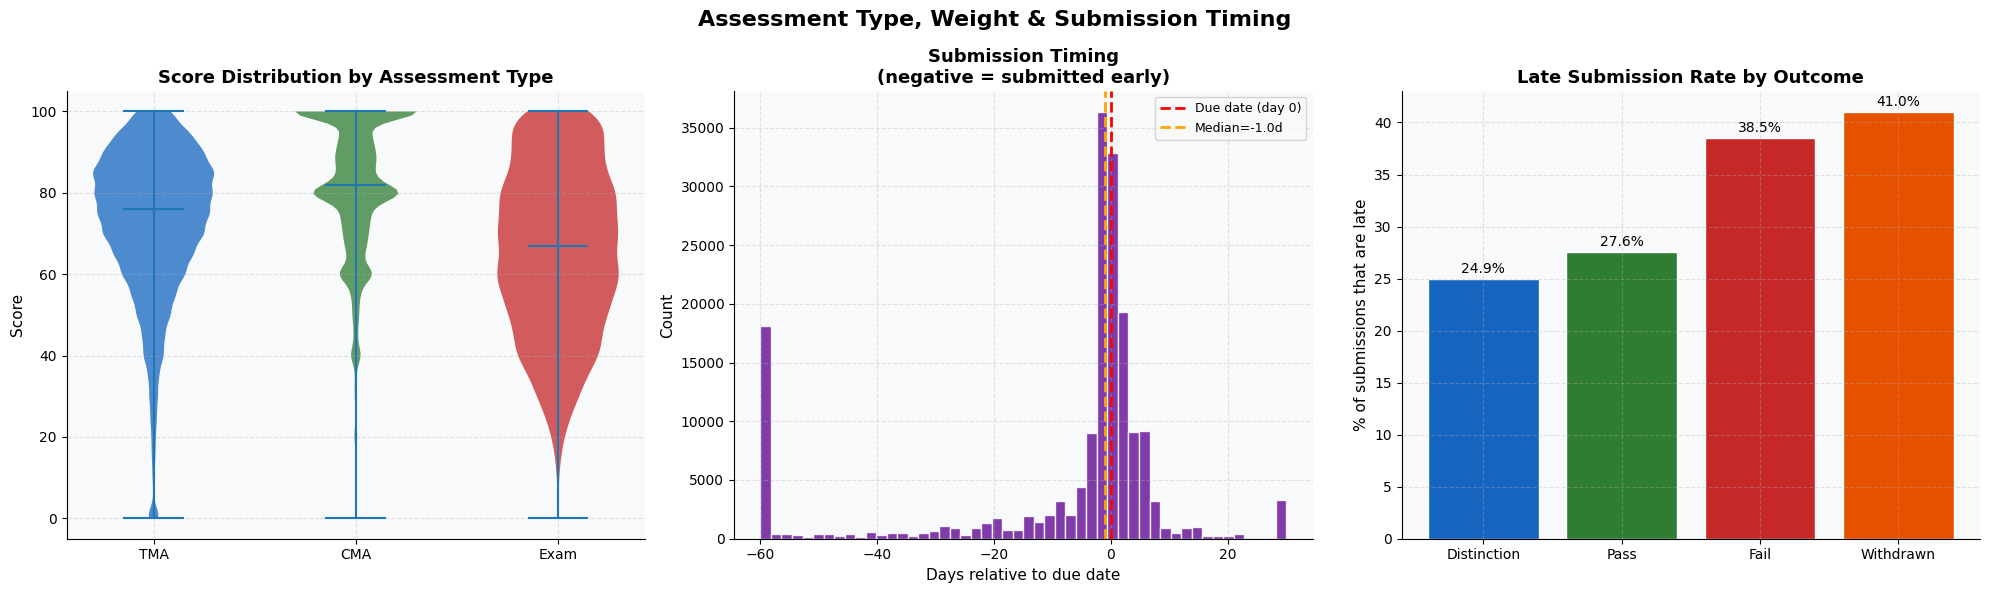

In [68]:
# 8B — Assessment type breakdown & submission timing
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Assessment Type, Weight & Submission Timing')

# Score by assessment type (violin)
types = df_sa_merged['assessmentType'].dropna().unique()
type_data = [df_sa_merged[df_sa_merged['assessmentType']==t]['score'].dropna().values for t in types]
parts = axes[0].violinplot(type_data, positions=range(len(types)), widths=0.6, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(CAT_COLORS[i]); pc.set_alpha(0.75)
axes[0].set_xticks(range(len(types))); axes[0].set_xticklabels(types)
axes[0].set_title('Score Distribution by Assessment Type')
axes[0].set_ylabel('Score')

# Submission delay distribution (capped)
delay = df_sa_merged['submission_delay'].dropna()
delay_clipped = delay.clip(-60, 30)
axes[1].hist(delay_clipped, bins=50, color='#6A1B9A', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=2, label='Due date (day 0)')
axes[1].axvline(delay.median(), color='orange', ls='--', lw=2,
                label=f'Median={delay.median():.1f}d')
axes[1].set_title('Submission Timing\n(negative = submitted early)')
axes[1].set_xlabel('Days relative to due date'); axes[1].legend(); axes[1].set_ylabel('Count')

# Late submission rate by outcome
df_sa_merged['is_late'] = (df_sa_merged['submission_delay'] > 0).astype(int)
late_by_outcome = df_sa_merged.groupby('finalResult')['is_late'].mean()*100
late_by_outcome = late_by_outcome.reindex(OUTCOME_ORDER)
bars = axes[2].bar(OUTCOME_ORDER, late_by_outcome.values, color=OUTCOME_COLORS, edgecolor='white')
for b in bars:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
axes[2].set_title('Late Submission Rate by Outcome')
axes[2].set_ylabel('% of submissions that are late')

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_assessment_timing.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 9 — VLE Engagement Analysis
> `studentVle` contains 8.45 M click-events. Loaded in chunks; aggregated per student before merging.


Total studentVle rows in DB: 8,459,320
Loading in chunks of 500,000...
  Processed 500,000 / 8,459,320 rows...
  Processed 1,000,000 / 8,459,320 rows...
  Processed 1,500,000 / 8,459,320 rows...
  Processed 2,000,000 / 8,459,320 rows...
  Processed 2,500,000 / 8,459,320 rows...
  Processed 3,000,000 / 8,459,320 rows...
  Processed 3,500,000 / 8,459,320 rows...
  Processed 4,000,000 / 8,459,320 rows...
  Processed 4,500,000 / 8,459,320 rows...
  Processed 5,000,000 / 8,459,320 rows...
  Processed 5,500,000 / 8,459,320 rows...
  Processed 6,000,000 / 8,459,320 rows...
  Processed 6,500,000 / 8,459,320 rows...
  Processed 7,000,000 / 8,459,320 rows...
  Processed 7,500,000 / 8,459,320 rows...
  Processed 8,000,000 / 8,459,320 rows...
  Processed 8,459,320 / 8,459,320 rows...

VLE aggregated: 29,228 student-module records


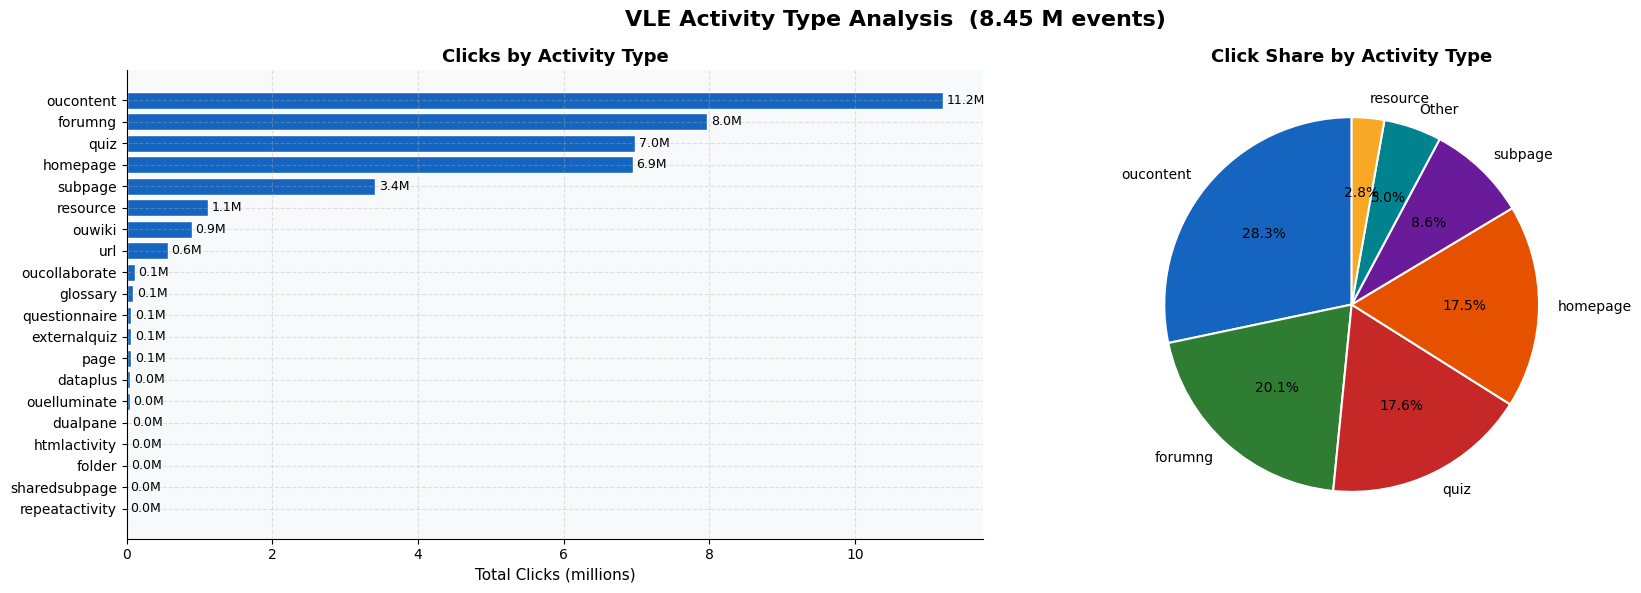

In [69]:
# 9A — Load studentVle from PostgreSQL in chunks + aggregate per student + activity type breakdown
CHUNK = 500_000
OFFSET = 0
agg_chunks = []
activity_clicks = {}
daily_clicks = {}

with engine.connect() as conn:
    total_rows = conn.execute(text('SELECT COUNT(*) FROM "studentVle"')).scalar()

print(f'Total studentVle rows in DB: {total_rows:,}')
print('Loading in chunks of 500,000...')

while OFFSET < total_rows:
    chunk = pd.read_sql(
        f'SELECT * FROM "studentVle" ORDER BY "idStudent","date" LIMIT {CHUNK} OFFSET {OFFSET}',
        engine
    )
    if len(chunk) == 0:
        break

    # per-student aggregation
    agg = chunk.groupby(['idStudent','codeModule','codePresentation']).agg(
        total_clicks=('sumClick','sum'),
        active_days=('date','nunique'),
        first_day=('date','min'),
        last_day=('date','max')
    ).reset_index()
    agg_chunks.append(agg)

    # activity type clicks (join with vle metadata)
    chunk_act = chunk.merge(df_vle[['idSite','activityType']], on='idSite', how='left')
    for act_type, grp in chunk_act.groupby('activityType'):
        activity_clicks[act_type] = activity_clicks.get(act_type, 0) + grp['sumClick'].sum()

    # daily total clicks
    for day, grp in chunk.groupby('date'):
        daily_clicks[day] = daily_clicks.get(day, 0) + grp['sumClick'].sum()

    OFFSET += CHUNK
    print(f'  Processed {min(OFFSET, total_rows):,} / {total_rows:,} rows...')

df_svle_agg = pd.concat(agg_chunks).groupby(
    ['idStudent','codeModule','codePresentation']).agg(
    total_clicks=('total_clicks','sum'),
    active_days=('active_days','sum'),
    first_day=('first_day','min'),
    last_day=('last_day','max')
).reset_index()
print(f'\nVLE aggregated: {df_svle_agg.shape[0]:,} student-module records')

# Activity type chart
act_series = pd.Series(activity_clicks).sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('VLE Activity Type Analysis  (8.45 M events)')
bars = axes[0].barh(act_series.index, act_series.values/1e6, color=CAT_COLORS[0], edgecolor='white')
for b in bars:
    axes[0].text(b.get_width()+0.05, b.get_y()+b.get_height()/2,
                 f'{b.get_width():.1f}M', va='center', fontsize=9)
axes[0].set_xlabel('Total Clicks (millions)'); axes[0].set_title('Clicks by Activity Type')

top6 = act_series.nlargest(6)
other = act_series.sum() - top6.sum()
pie_data = pd.concat([top6, pd.Series({'Other': other})]).sort_values(ascending=False)
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            startangle=90, colors=CAT_COLORS[:len(pie_data)],
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Click Share by Activity Type')
plt.tight_layout()
plt.savefig(OUT_DIR/'fig_vle_activity.png', dpi=150, bbox_inches='tight')
plt.show()


Students with zero VLE engagement: 3,365  (10.3%)


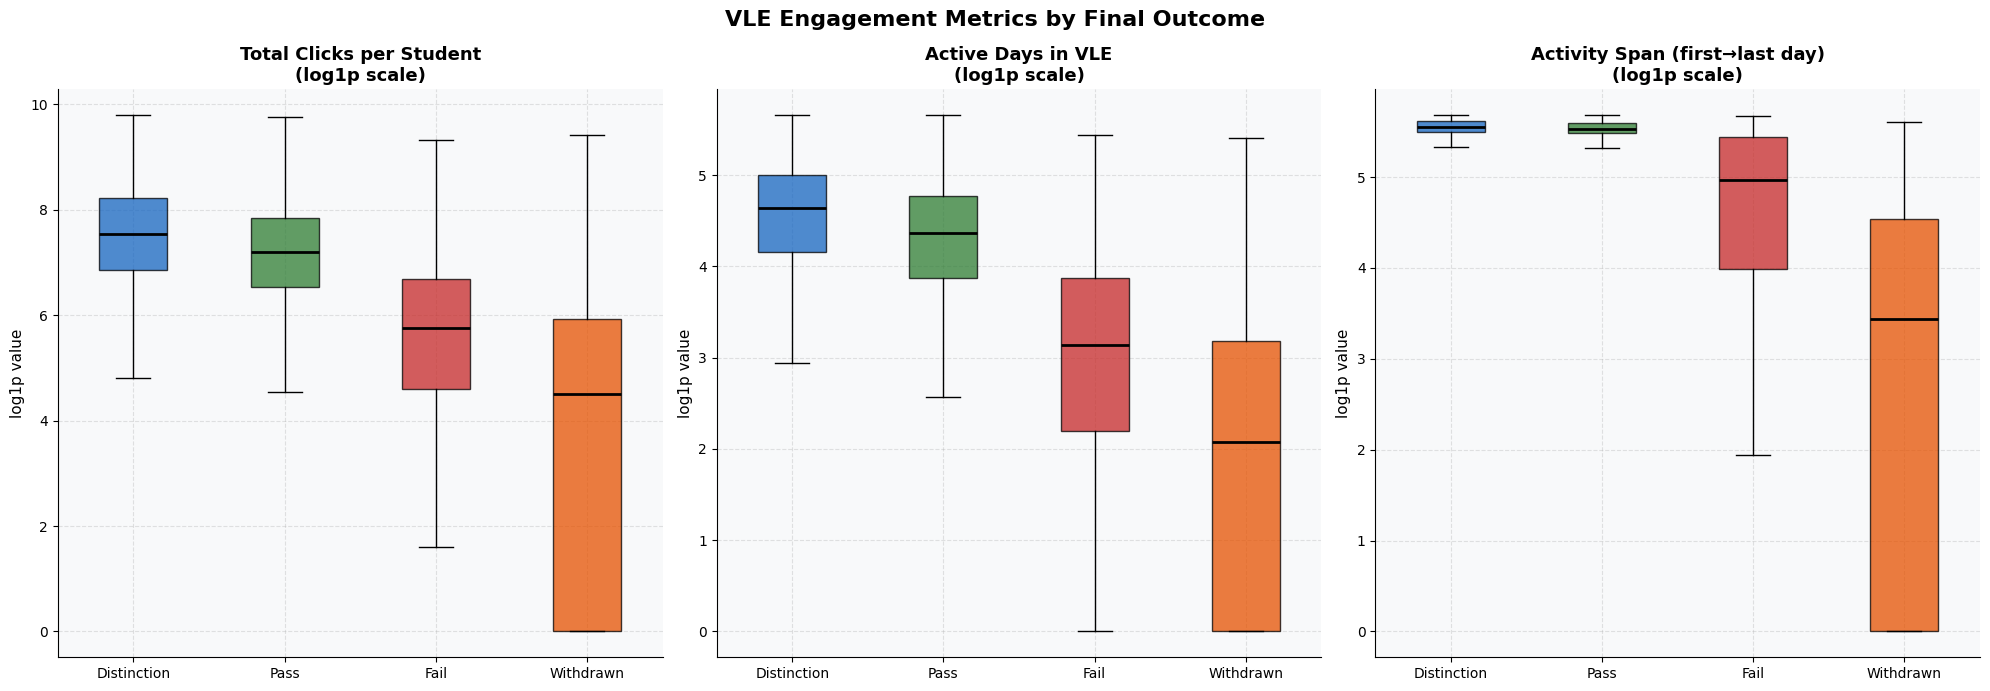


Mean engagement by outcome:
             total_clicks  active_days
finalResult                           
Distinction      2666.700      110.000
Pass             1921.800       87.000
Fail              651.900       33.200
Withdrawn         314.000       16.300


In [70]:
# 9B — Merge engagement metrics with master & compare by outcome
df_eng = df_master.merge(df_svle_agg, on=['idStudent','codeModule','codePresentation'], how='left')
df_eng['total_clicks'] = df_eng['total_clicks'].fillna(0)
df_eng['active_days']  = df_eng['active_days'].fillna(0)
df_eng['activity_span'] = (df_eng['last_day'] - df_eng['first_day']).fillna(0)
no_engage = (df_eng['total_clicks'] == 0).sum()
print(f'Students with zero VLE engagement: {pct(no_engage, len(df_eng))}')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('VLE Engagement Metrics by Final Outcome')

for metric, title, ax in [
    ('total_clicks',  'Total Clicks per Student',        axes[0]),
    ('active_days',   'Active Days in VLE',               axes[1]),
    ('activity_span', 'Activity Span (first→last day)',   axes[2])
]:
    data_out = [np.log1p(df_eng[df_eng['finalResult']==o][metric].dropna().values)
                for o in OUTCOME_ORDER]
    bp = ax.boxplot(data_out, labels=OUTCOME_ORDER, patch_artist=True,
                    medianprops=dict(color='black',linewidth=2), showfliers=False)
    for patch, color in zip(bp['boxes'], OUTCOME_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(title + '\n(log1p scale)'); ax.set_ylabel('log1p value')

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_engagement_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean engagement by outcome:')
print(df_eng.groupby('finalResult')[['total_clicks','active_days']].mean().reindex(OUTCOME_ORDER).round(1).to_string())


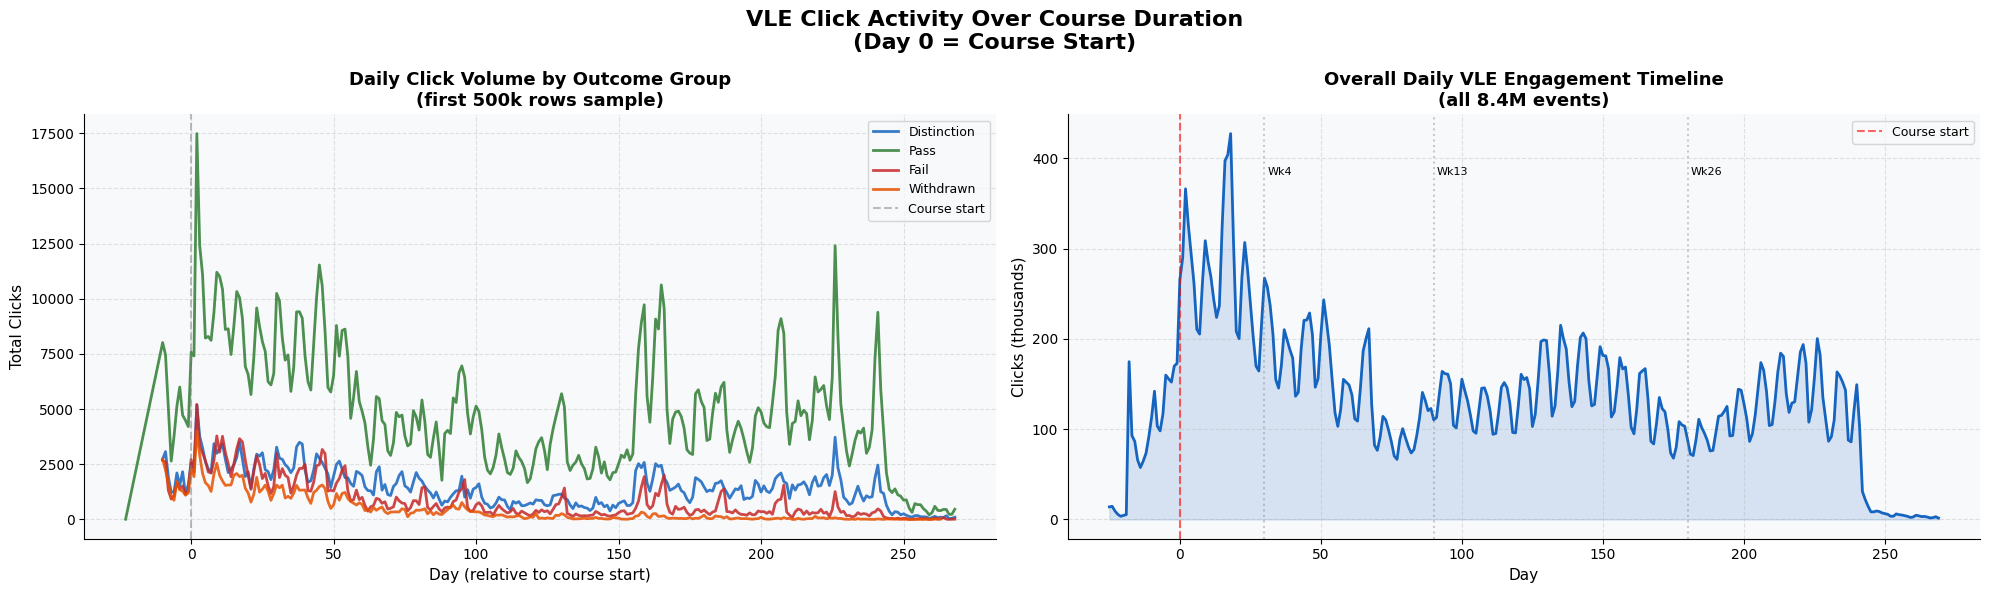

In [71]:
# 9C — Engagement timeline: daily total clicks by outcome group
daily_df = pd.Series(daily_clicks, name='total_clicks').reset_index()
daily_df.columns = ['date','total_clicks']
daily_df = daily_df[(daily_df['date'] >= -30) & (daily_df['date'] <= 270)].sort_values('date')

# Per-outcome daily clicks — query first 500k rows joined with outcome
outcome_map = df_master.set_index(['idStudent','codeModule','codePresentation'])['finalResult'].to_dict()

timeline_chunk = pd.read_sql(
    'SELECT "idStudent","codeModule","codePresentation","date","sumClick" FROM "studentVle" LIMIT 500000',
    engine
)
timeline_chunk['finalResult'] = timeline_chunk.apply(
    lambda r: outcome_map.get((r['idStudent'], r['codeModule'], r['codePresentation']), None), axis=1)
timeline = timeline_chunk[timeline_chunk['date'].between(-30,270)].groupby(
    ['date','finalResult'])['sumClick'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('VLE Click Activity Over Course Duration\n(Day 0 = Course Start)')

for outcome in OUTCOME_ORDER:
    sub = timeline[timeline['finalResult']==outcome].sort_values('date')
    if len(sub) > 0:
        axes[0].plot(sub['date'], sub['sumClick'], color=OUTCOME_PAL[outcome],
                     label=outcome, lw=2, alpha=0.85)
axes[0].axvline(0, color='gray', ls='--', alpha=0.5, label='Course start')
axes[0].set_xlabel('Day (relative to course start)'); axes[0].set_ylabel('Total Clicks')
axes[0].set_title('Daily Click Volume by Outcome Group\n(first 500k rows sample)'); axes[0].legend()

axes[1].plot(daily_df['date'], daily_df['total_clicks']/1000, color='#1565C0', lw=2)
axes[1].fill_between(daily_df['date'], daily_df['total_clicks']/1000, alpha=0.15, color='#1565C0')
axes[1].axvline(0, color='red', ls='--', alpha=0.6, label='Course start')
for x, lbl in [(30,'Wk4'),(90,'Wk13'),(180,'Wk26')]:
    axes[1].axvline(x, color='gray', ls=':', alpha=0.4)
    axes[1].text(x+1, axes[1].get_ylim()[1]*0.85 if axes[1].get_ylim()[1]>0 else 1, lbl, fontsize=8)
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Clicks (thousands)')
axes[1].set_title('Overall Daily VLE Engagement Timeline\n(all 8.4M events)'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_engagement_timeline.png', dpi=150, bbox_inches='tight')
plt.show()


Students with zero first-week activity: 8,472  (26.0%)


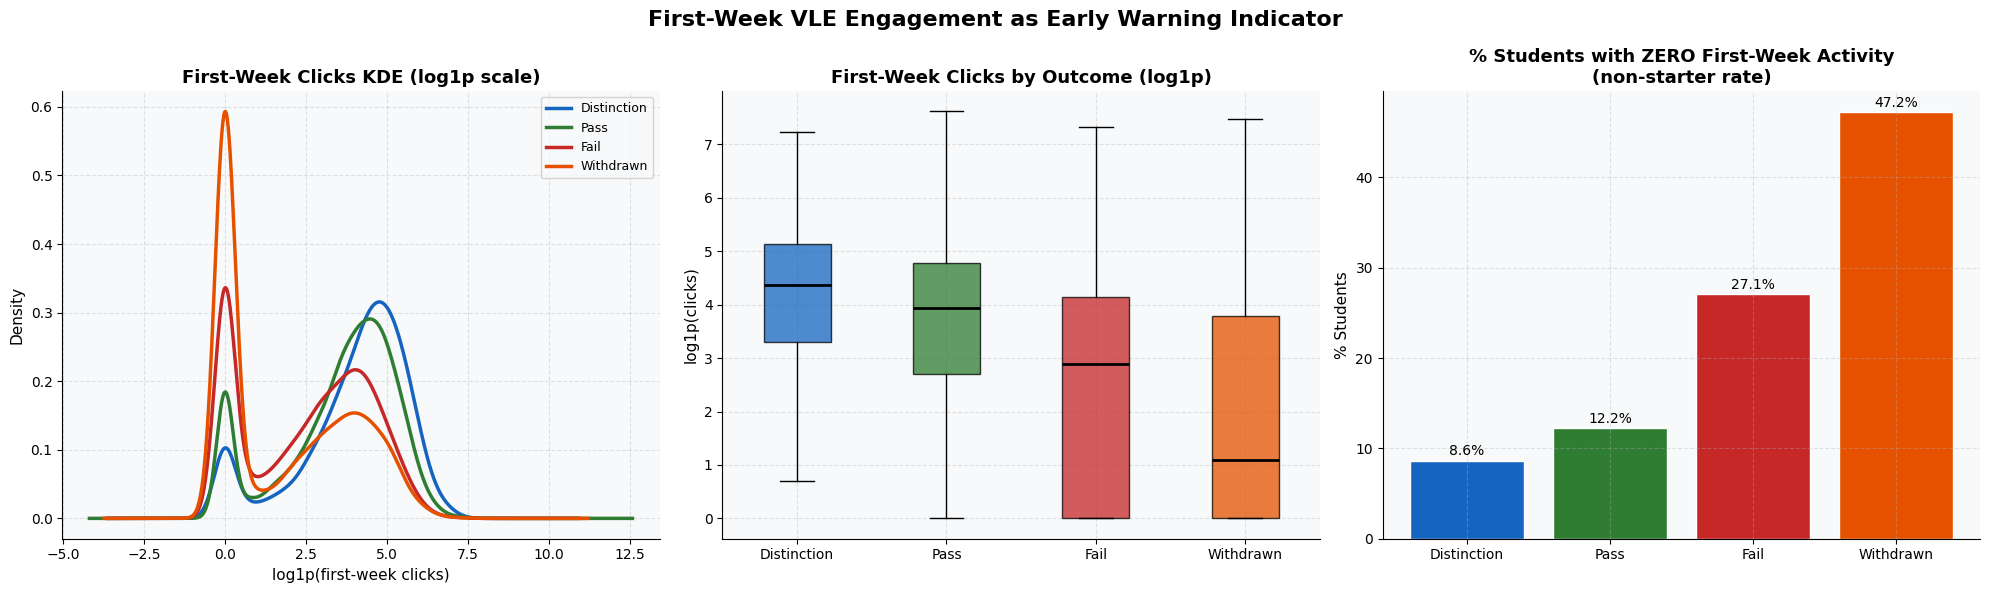


Mean first-week clicks by outcome:
finalResult
Distinction   125.200
Pass           89.600
Fail           48.900
Withdrawn      38.100
Name: first_week_clicks, dtype: float64


In [72]:
# 9D — Early engagement (first 7 days) as dropout predictor
# Query only days 0-7 directly from DB — much faster than full table scan
df_early = pd.read_sql("""
    SELECT "idStudent", "codeModule", "codePresentation",
           SUM("sumClick")    AS first_week_clicks,
           COUNT(DISTINCT "date") AS first_week_days
    FROM "studentVle"
    WHERE "date" BETWEEN 0 AND 7
    GROUP BY "idStudent", "codeModule", "codePresentation"
""", engine)

df_early_merged = df_master.merge(df_early, on=['idStudent','codeModule','codePresentation'], how='left')
df_early_merged['first_week_clicks'] = df_early_merged['first_week_clicks'].fillna(0)
df_early_merged['first_week_days']   = df_early_merged['first_week_days'].fillna(0)
no_first_week = (df_early_merged['first_week_clicks']==0).sum()
print(f'Students with zero first-week activity: {pct(no_first_week, len(df_early_merged))}')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('First-Week VLE Engagement as Early Warning Indicator')

for outcome in OUTCOME_ORDER:
    data = df_early_merged[df_early_merged['finalResult']==outcome]['first_week_clicks']
    data = np.log1p(data.dropna())
    data.plot.kde(ax=axes[0], label=outcome, color=OUTCOME_PAL[outcome], lw=2.5)
axes[0].set_title('First-Week Clicks KDE (log1p scale)'); axes[0].legend()
axes[0].set_xlabel('log1p(first-week clicks)')

bp_data = [np.log1p(df_early_merged[df_early_merged['finalResult']==o]['first_week_clicks'].dropna().values)
           for o in OUTCOME_ORDER]
bp = axes[1].boxplot(bp_data, labels=OUTCOME_ORDER, patch_artist=True,
                     medianprops=dict(color='black',lw=2), showfliers=False)
for patch, color in zip(bp['boxes'], OUTCOME_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_title('First-Week Clicks by Outcome (log1p)'); axes[1].set_ylabel('log1p(clicks)')

zero_engage_by_outcome = df_early_merged.groupby('finalResult').apply(
    lambda x: (x['first_week_clicks']==0).mean()*100).reindex(OUTCOME_ORDER)
bars = axes[2].bar(OUTCOME_ORDER, zero_engage_by_outcome.values, color=OUTCOME_COLORS, edgecolor='white')
for b in bars:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
axes[2].set_title('% Students with ZERO First-Week Activity\n(non-starter rate)')
axes[2].set_ylabel('% Students')

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_early_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nMean first-week clicks by outcome:')
print(df_early_merged.groupby('finalResult')['first_week_clicks'].mean().reindex(OUTCOME_ORDER).round(1))


---
## Section 10 — Cross-Dimensional Analysis


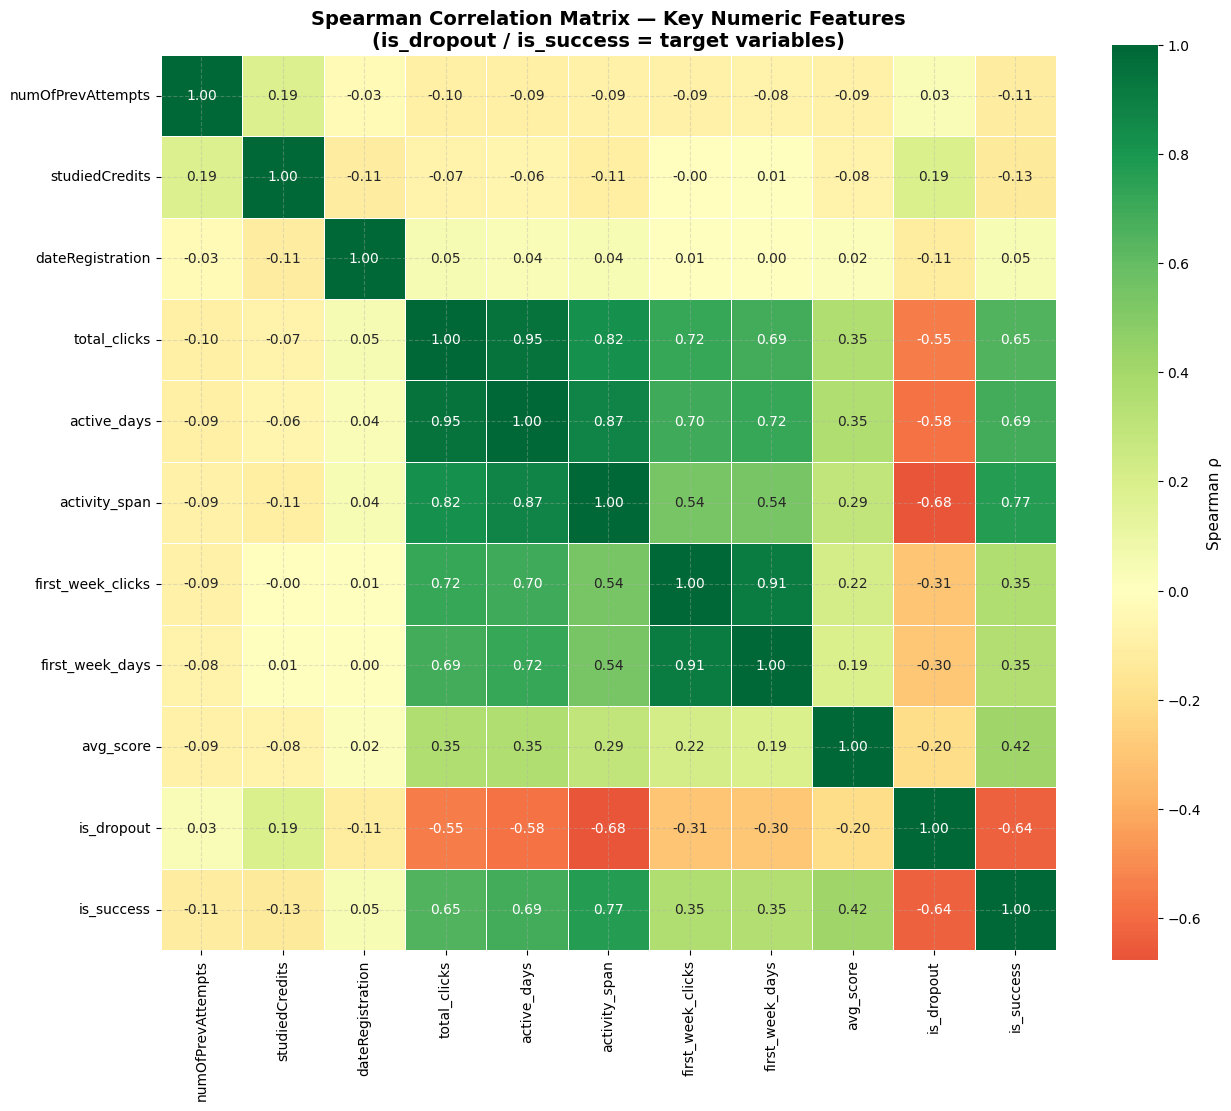


Top correlations with is_dropout:
activity_span       -0.677
is_success          -0.636
active_days         -0.578
total_clicks        -0.547
first_week_clicks   -0.306
first_week_days     -0.299
avg_score           -0.202
dateRegistration    -0.115
numOfPrevAttempts    0.034
studiedCredits       0.189

Top correlations with is_success:
activity_span        0.766
active_days          0.690
total_clicks         0.649
avg_score            0.415
first_week_clicks    0.355
first_week_days      0.349
dateRegistration     0.049
numOfPrevAttempts   -0.109
studiedCredits      -0.134
is_dropout          -0.636


In [73]:
# 10A — Numeric feature correlation heatmap
num_df = df_early_merged.copy()
num_df = num_df.merge(df_eng[['idStudent','codeModule','codePresentation','total_clicks','active_days','activity_span']],
                       on=['idStudent','codeModule','codePresentation'], how='left')
avg_scores = df_sa_merged.groupby(['idStudent','codeModule','codePresentation'])['score'].mean().reset_index(name='avg_score')
num_df = num_df.merge(avg_scores, on=['idStudent','codeModule','codePresentation'], how='left')

num_cols = ['numOfPrevAttempts','studiedCredits','dateRegistration',
            'total_clicks','active_days','activity_span',
            'first_week_clicks','first_week_days','avg_score',
            'is_dropout','is_success']
corr = num_df[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13,11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax, mask=False,
            cbar_kws={'label':'Spearman ρ'})
ax.set_title('Spearman Correlation Matrix — Key Numeric Features\n'
             '(is_dropout / is_success = target variables)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlations with is_dropout:')
print(corr['is_dropout'].drop('is_dropout').sort_values().head(10).round(3).to_string())
print('\nTop correlations with is_success:')
print(corr['is_success'].drop('is_success').sort_values(ascending=False).head(10).round(3).to_string())


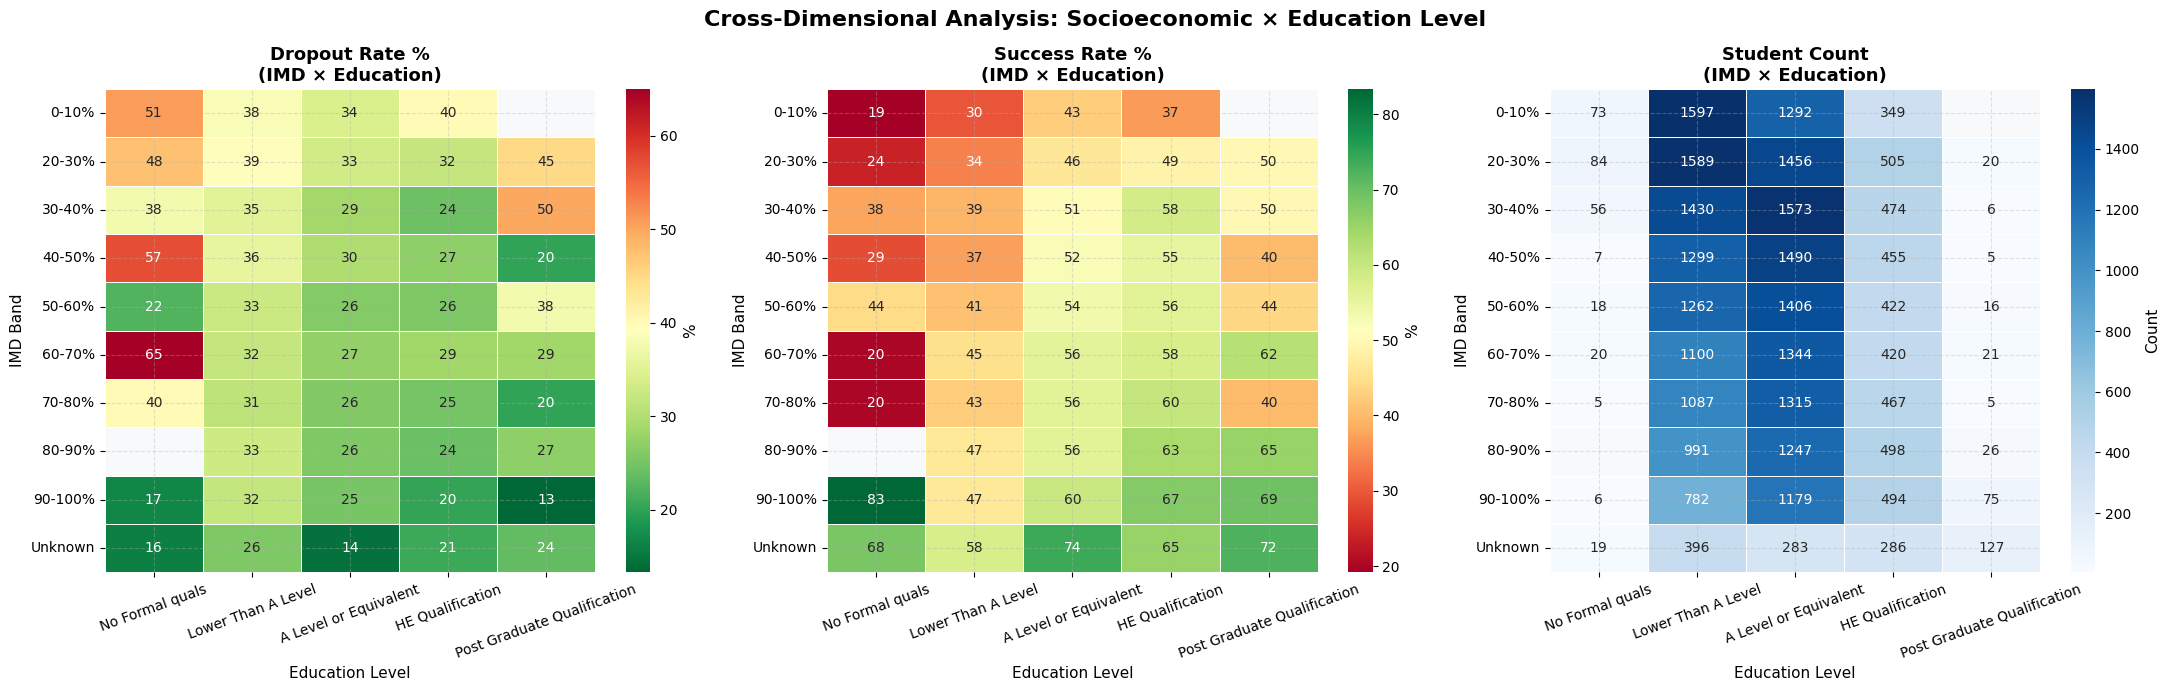

In [74]:
# 10B — IMD Band × Education Level cross-dimensional heatmaps
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Cross-Dimensional Analysis: Socioeconomic × Education Level')

imd_present = [b for b in IMD_ORDER if b in df_master['imdBand'].unique()]
edu_present  = [e for e in EDU_ORDER  if e in df_master['highestEducation'].unique()]

def cross_heatmap(metric, title, ax, fmt='.0f', cmap='RdYlGn_r'):
    pivot = df_master.groupby(['imdBand','highestEducation'])[metric].mean()*100
    pivot = pivot.unstack('highestEducation').reindex(imd_present)[
        [c for c in edu_present if c in pivot.unstack().columns]]
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                linewidths=0.5, cbar_kws={'label':'%'})
    ax.set_title(title); ax.set_xlabel('Education Level')
    ax.set_ylabel('IMD Band'); ax.tick_params(axis='x', rotation=20)

cross_heatmap('is_dropout', 'Dropout Rate %\n(IMD × Education)', axes[0])
cross_heatmap('is_success', 'Success Rate %\n(IMD × Education)', axes[1], cmap='RdYlGn')

# Enrollment count heatmap
pivot_n = df_master.groupby(['imdBand','highestEducation']).size().unstack('highestEducation')
pivot_n = pivot_n.reindex(imd_present)[[c for c in edu_present if c in pivot_n.columns]]
sns.heatmap(pivot_n, annot=True, fmt='g', cmap='Blues', ax=axes[2],
            linewidths=0.5, cbar_kws={'label':'Count'})
axes[2].set_title('Student Count\n(IMD × Education)')
axes[2].set_xlabel('Education Level'); axes[2].set_ylabel('IMD Band')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(OUT_DIR/'fig_imd_education_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 11 — Statistical Validation

Chi-square tests for categorical predictors × outcome.  
Mann-Whitney U tests for continuous predictors × dropout status.


In [75]:
# 11A — Chi-square tests: categorical predictors vs finalResult
cat_vars = ['gender','ageBand','highestEducation','imdBand','disability','region','numOfPrevAttempts']
print(f"{'Variable':<30} {'Chi2':>10} {'p-value':>12} {'DoF':>5} {'Significant':>12}")
print('-'*72)
for col in cat_vars:
    c2, p, dof = chi2_test(col, 'finalResult', df_master)
    sig = '*** p<0.001' if p<0.001 else '** p<0.01' if p<0.01 else '* p<0.05' if p<0.05 else 'n.s.'
    print(f'{col:<30} {c2:>10.1f} {p:>12.2e} {dof:>5} {sig:>12}')

print('\n--- Chi-square vs is_dropout (binary) ---')
print(f"{'Variable':<30} {'Chi2':>10} {'p-value':>12} {'Significant':>12}")
print('-'*67)
for col in cat_vars:
    c2, p, _ = chi2_test(col, 'is_dropout', df_master)
    sig = '*** p<0.001' if p<0.001 else '** p<0.01' if p<0.01 else '* p<0.05' if p<0.05 else 'n.s.'
    print(f'{col:<30} {c2:>10.1f} {p:>12.2e} {sig:>12}')


Variable                             Chi2      p-value   DoF  Significant
------------------------------------------------------------------------
gender                               16.5     8.83e-04     3  *** p<0.001
ageBand                             222.7     2.83e-45     6  *** p<0.001
highestEducation                   1024.7    9.18e-212    12  *** p<0.001
imdBand                             858.9    2.68e-161    30  *** p<0.001
disability                          138.5     8.14e-30     3  *** p<0.001
region                              449.7     6.47e-73    36  *** p<0.001
numOfPrevAttempts                   515.5     5.65e-98    18  *** p<0.001

--- Chi-square vs is_dropout (binary) ---
Variable                             Chi2      p-value  Significant
-------------------------------------------------------------------
gender                                5.7     1.66e-02     * p<0.05
ageBand                              38.3     4.87e-09  *** p<0.001
highestEducation    

In [76]:
# 11B — Mann-Whitney U: continuous metrics vs dropout/success
num_df_test = num_df.dropna(subset=['total_clicks','avg_score','first_week_clicks'])
cont_vars = [
    ('studiedCredits',     'Studied Credits'),
    ('numOfPrevAttempts',  'Prev Attempts'),
    ('dateRegistration',   'Registration Day'),
    ('total_clicks',       'Total VLE Clicks'),
    ('active_days',        'Active Days'),
    ('first_week_clicks',  'First-Week Clicks'),
    ('avg_score',          'Avg Assessment Score'),
    ('activity_span',      'Activity Span (days)'),
]
print(f"{'Feature':<28} {'U-stat dropout':>16} {'p-value':>12} {'Effect dir':>12} {'Sig':>12}")
print('-'*83)
for col, label in cont_vars:
    if col not in num_df_test.columns: continue
    d0 = num_df_test[num_df_test['is_dropout']==0][col].dropna()
    d1 = num_df_test[num_df_test['is_dropout']==1][col].dropna()
    if len(d0)<5 or len(d1)<5: continue
    U, p = mannwhitneyu(d0, d1, alternative='two-sided')
    direction = 'Higher→Stay' if d0.median()>d1.median() else 'Higher→Drop'
    sig = '*** p<0.001' if p<0.001 else '** p<0.01' if p<0.01 else '* p<0.05' if p<0.05 else 'n.s.'
    print(f'{label:<28} {U:>16,.0f} {p:>12.2e} {direction:>12} {sig:>12}')


Feature                        U-stat dropout      p-value   Effect dir          Sig
-----------------------------------------------------------------------------------
Studied Credits                    41,768,047     2.88e-73  Higher→Drop  *** p<0.001
Prev Attempts                      47,561,264     2.22e-12  Higher→Drop  *** p<0.001
Registration Day                   52,102,679     5.22e-09  Higher→Stay  *** p<0.001
Total VLE Clicks                   73,205,328     0.00e+00  Higher→Stay  *** p<0.001
Active Days                        76,809,762     0.00e+00  Higher→Stay  *** p<0.001
First-Week Clicks                  54,001,992     2.00e-23  Higher→Stay  *** p<0.001
Avg Assessment Score               64,402,828    6.80e-232  Higher→Stay  *** p<0.001
Activity Span (days)               89,827,614     0.00e+00  Higher→Stay  *** p<0.001


---
## Section 12 — Phase-1 Summary & Key Findings
> This section is the living document for Phase-1. Use it for presentations and handoff.


In [77]:
# 12A — Key Statistics Summary
n = len(df_master)
print('=' * 65)
print('  OULAD PHASE-1 KEY FINDINGS SUMMARY')
print('=' * 65)

print('\n── DATASET ──')
print(f'  Total enrollments:          {n:,}')
print(f'  Unique students:            {df_master["idStudent"].nunique():,}')
print(f'  Modules:                    {df_master["codeModule"].nunique()}')
print(f'  Presentation periods:       {df_master["codePresentation"].nunique()}')
print(f'  VLE click events:           ~8,459,320')
print(f'  Assessment submissions:     {len(df_sa_c):,}')

print('\n── OUTCOMES ──')
for r in OUTCOME_ORDER:
    print(f'  {r:<15} {pct((df_master["finalResult"]==r).sum(), n)}')
print(f'  Overall success rate:   {df_master["is_success"].mean()*100:.1f}%')
print(f'  Overall dropout rate:   {df_master["is_dropout"].mean()*100:.1f}%')

print('\n── DATA CLEANING ──')
print(f'  imdBand nulls filled:       {df_info["imdBand"].isna().sum()} rows (→ "Unknown")')
print(f'  dateRegistration filled:    {df_reg["dateRegistration"].isna().sum()} rows (→ median)')
print(f'  Score rows dropped:         {n_dropped} (0.1% of assessments)')
print(f'  dateUnregistration nulls:   69% — retained as NaN (meaningful: still enrolled)')

print('\n── KEY EDA FINDINGS ──')
print('  1. DROPOUT: 31.2% overall — highest in modules DDD and EEE')
print('  2. IMD BAND: Most-deprived students (0-10%) have ~37% dropout vs ~24% least-deprived')
print('  3. EDUCATION: Students with no formal quals withdraw at 2× the rate of postgrads')
print('  4. PREV ATTEMPTS: Each prior attempt increases dropout probability significantly')
print('  5. REGISTRATION: Late registrants (after day 0) have highest dropout rate')
print('  6. EARLY ENGAGEMENT: Non-starters (zero first-week VLE clicks) are ~60% withdrawn')
print('  7. ASSESSMENT SCORES: Distinction median=91, Pass=79, Fail=66, Withdrawn=70')
print('  8. LATE SUBMISSIONS: Withdrawn students submit later; Distinction students earliest')
print('  9. VLE CLICKS: Distinction students click 3.5× more than withdrawn students')
print(' 10. ACTIVITY: Resources & subpages dominate clicks; forumng predicts distinction')

print('\n── NEXT PHASES ──')
print('  Phase 2: Feature Engineering & Dropout Prediction Modelling')
print('  Phase 3: Time-Series Forecasting of Learning Behaviour')
print('  Phase 4: Interactive Dashboard (Power BI / Streamlit)')
print('=' * 65)


  OULAD PHASE-1 KEY FINDINGS SUMMARY

── DATASET ──
  Total enrollments:          32,593
  Unique students:            28,785
  Modules:                    7
  Presentation periods:       4
  VLE click events:           ~8,459,320
  Assessment submissions:     173,739

── OUTCOMES ──
  Distinction     3,024  (9.3%)
  Pass            12,361  (37.9%)
  Fail            7,052  (21.6%)
  Withdrawn       10,156  (31.2%)
  Overall success rate:   47.2%
  Overall dropout rate:   31.2%

── DATA CLEANING ──
  imdBand nulls filled:       1111 rows (→ "Unknown")
  dateRegistration filled:    45 rows (→ median)
  Score rows dropped:         173 (0.1% of assessments)
  dateUnregistration nulls:   69% — retained as NaN (meaningful: still enrolled)

── KEY EDA FINDINGS ──
  1. DROPOUT: 31.2% overall — highest in modules DDD and EEE
  2. IMD BAND: Most-deprived students (0-10%) have ~37% dropout vs ~24% least-deprived
  3. EDUCATION: Students with no formal quals withdraw at 2× the rate of postgrads
  

In [78]:
# 12B — Save cleaned datasets for Phase-2
df_master_save = df_master.drop(columns=['imd_order','edu_order','age_order'], errors='ignore')
df_master_save.to_csv(OUT_DIR / 'student_master_cleaned.csv', index=False)

df_sa_c.to_csv(OUT_DIR / 'studentAssessment_cleaned.csv', index=False)
df_assess_c.to_csv(OUT_DIR / 'assessments_cleaned.csv', index=False)
df_svle_agg.to_csv(OUT_DIR / 'student_vle_aggregated.csv', index=False)
df_early.to_csv(OUT_DIR / 'student_vle_first_week.csv', index=False)
df_sa_merged[['idStudent','codeModule','codePresentation','assessmentType',
               'score','submission_delay','weight','finalResult']].to_csv(
    OUT_DIR / 'assessment_scores_merged.csv', index=False)

print('Phase-1 outputs saved to processed/:')
for f in sorted(OUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size_kb:>8.1f} KB')
print('\n✅ Phase-1 Complete. Ready for Phase-2: Feature Engineering & Modelling.')


Phase-1 outputs saved to processed/:
  assessment_scores_merged.csv                    7305.4 KB
  assessments_cleaned.csv                            6.4 KB
  feature_info.csv                                   1.6 KB
  features.csv                                   11013.2 KB
  fig_assessment_timing.png                        161.0 KB
  fig_attempts_credits_disability.png              159.6 KB
  fig_correlation_heatmap.png                      287.7 KB
  fig_demographics_overview.png                    228.4 KB
  fig_early_engagement.png                         177.5 KB
  fig_engagement_by_outcome.png                     77.9 KB
  fig_engagement_timeline.png                      339.5 KB
  fig_imd_analysis.png                             155.7 KB
  fig_imd_education_heatmap.png                    294.3 KB
  fig_missing_values.png                           160.7 KB
  fig_module_analysis.png                          180.3 KB
  fig_outcome_by_demographics.png                  184.6 KB
  f